In [1]:
# =========================
# CELL 1: IMPORT LIBRARIES
# =========================

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import librosa
    import librosa.display
    HAS_LIBROSA = True
except ImportError:
    HAS_LIBROSA = False
    print("librosa belum terinstall. Bagian audio waveform/log-mel akan dilewati.")

try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print("scikit-learn belum terinstall. Bagian PCA embedding akan dilewati.")

In [2]:
# =========================
# CELL 2: PATH CONFIGURATION
# =========================

ROOT = Path(r"E:\tugas-akhir-qiqi")

PREPROCESSING_DIR = ROOT / "output" / "preprocessing"

META_TRAIN_PATH = PREPROCESSING_DIR / "meta_train_official.csv"
META_VAL_PATH   = PREPROCESSING_DIR / "meta_val_official.csv"
META_TEST_PATH  = PREPROCESSING_DIR / "meta_test_official.csv"

AUDIO_DIR = PREPROCESSING_DIR / "preprocessed_full"

VAD_DIR = PREPROCESSING_DIR / "vad"
VAD_REPORT_PATH = VAD_DIR / "vad_report.csv"
VAD_DROP_PATH = VAD_DIR / "vad_drop.csv"

BASELINE_OFFICIAL_DIR = ROOT / "output" / "V1" / "baseline_official"

EGEMAPS_DIR = BASELINE_OFFICIAL_DIR / "egemaps"
EGEMAPS_TRAIN_PATH = EGEMAPS_DIR / "train_egemaps.csv"
EGEMAPS_VAL_PATH   = EGEMAPS_DIR / "val_egemaps.csv"
EGEMAPS_TEST_PATH  = EGEMAPS_DIR / "test_egemaps.csv"

EMBEDDING_ROOT = BASELINE_OFFICIAL_DIR / "embeddings"

SSL_DIRS = {
    "hubert": EMBEDDING_ROOT / "hubert",
    "wav2vec2": EMBEDDING_ROOT / "wav2vec2",
    "wavlm": EMBEDDING_ROOT / "wavlm",
}

# Output notebook EDA di current working directory
OUTPUT_DIR = Path.cwd() / "output"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
AUDIO_EXAMPLE_DIR = OUTPUT_DIR / "audio_examples"
REPORT_DIR = OUTPUT_DIR / "reports"

for d in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, AUDIO_EXAMPLE_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Output folder:", OUTPUT_DIR)

Output folder: e:\tugas-akhir-qiqi\code\V2\output


In [3]:
# =========================
# CELL 3: HELPER FUNCTIONS
# =========================

def save_table(df, filename, index=False):
    path = TABLE_DIR / filename
    df.to_csv(path, index=index)
    print("Saved table:", path)
    return path


def save_fig(filename):
    path = FIGURE_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved figure:", path)
    return path


def save_audio_fig(filename):
    path = AUDIO_EXAMPLE_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved audio figure:", path)
    return path


def check_file(path):
    path = Path(path)
    print(f"{path}: {'FOUND' if path.exists() else 'MISSING'}")
    return path.exists()


def display_shape_and_head(df, name, n=5):
    print(f"{name} shape:", df.shape)
    display(df.head(n))

In [4]:
# =========================
# CELL 4: CHECK REQUIRED FILES
# =========================

required_files = [
    META_TRAIN_PATH,
    META_VAL_PATH,
    META_TEST_PATH,
    VAD_REPORT_PATH,
    VAD_DROP_PATH,
    EGEMAPS_TRAIN_PATH,
    EGEMAPS_VAL_PATH,
    EGEMAPS_TEST_PATH,
]

for path in required_files:
    check_file(path)

print("\nAudio folder exists:", AUDIO_DIR.exists())
print("Audio folder:", AUDIO_DIR)

for model_name, model_dir in SSL_DIRS.items():
    print(f"\n{model_name} dir:", model_dir)
    check_file(model_dir / "train_emb.npy")
    check_file(model_dir / "val_emb.npy")
    check_file(model_dir / "test_emb.npy")
    check_file(model_dir / "train_clip_id.csv")
    check_file(model_dir / "val_clip_id.csv")
    check_file(model_dir / "test_clip_id.csv")

E:\tugas-akhir-qiqi\output\preprocessing\meta_train_official.csv: FOUND
E:\tugas-akhir-qiqi\output\preprocessing\meta_val_official.csv: FOUND
E:\tugas-akhir-qiqi\output\preprocessing\meta_test_official.csv: FOUND
E:\tugas-akhir-qiqi\output\preprocessing\vad\vad_report.csv: FOUND
E:\tugas-akhir-qiqi\output\preprocessing\vad\vad_drop.csv: FOUND
E:\tugas-akhir-qiqi\output\V1\baseline_official\egemaps\train_egemaps.csv: FOUND
E:\tugas-akhir-qiqi\output\V1\baseline_official\egemaps\val_egemaps.csv: FOUND
E:\tugas-akhir-qiqi\output\V1\baseline_official\egemaps\test_egemaps.csv: FOUND

Audio folder exists: True
Audio folder: E:\tugas-akhir-qiqi\output\preprocessing\preprocessed_full

hubert dir: E:\tugas-akhir-qiqi\output\V1\baseline_official\embeddings\hubert
E:\tugas-akhir-qiqi\output\V1\baseline_official\embeddings\hubert\train_emb.npy: FOUND
E:\tugas-akhir-qiqi\output\V1\baseline_official\embeddings\hubert\val_emb.npy: FOUND
E:\tugas-akhir-qiqi\output\V1\baseline_official\embeddings\huber

In [5]:
# =========================
# CELL 5: LOAD OFFICIAL METADATA
# =========================

df_train = pd.read_csv(META_TRAIN_PATH)
df_val = pd.read_csv(META_VAL_PATH)
df_test = pd.read_csv(META_TEST_PATH)

df_train["split_official"] = "train"
df_val["split_official"] = "val"
df_test["split_official"] = "test"

display_shape_and_head(df_train, "df_train")
display_shape_and_head(df_val, "df_val")
display_shape_and_head(df_test, "df_test")

df_train shape: (6000, 13)


,group_id,clip_id,split_official,VideoName,Ethnicity,Gender,AgeGroup,extraversion,neuroticism,agreeableness,conscientiousness,openness,interview
0,--Ymqszjv54,--Ymqszjv54.001,train,--Ymqszjv54.001.mp4,2,1,5,0.551402,0.500000,0.527473,0.650485,0.744444,0.588785
1,--Ymqszjv54,--Ymqszjv54.003,train,--Ymqszjv54.003.mp4,2,1,5,0.392523,0.427083,0.516484,0.475728,0.466667,0.392523
2,--Ymqszjv54,--Ymqszjv54.004,train,--Ymqszjv54.004.mp4,2,1,5,0.317757,0.322917,0.549451,0.368932,0.544444,0.401869
3,--Ymqszjv54,--Ymqszjv54.005,train,--Ymqszjv54.005.mp4,2,1,5,0.299065,0.291667,0.373626,0.320388,0.344444,0.280374
4,-2qsCrkXdWs,-2qsCrkXdWs.001,train,-2qsCrkXdWs.001.mp4,2,1,2,0.476636,0.604167,0.593407,0.572816,0.611111,0.560748


df_val shape: (2000, 13)


,group_id,clip_id,split_official,VideoName,Ethnicity,Gender,AgeGroup,extraversion,neuroticism,agreeableness,conscientiousness,openness,interview
0,-6otZ7M-Mro,-6otZ7M-Mro.003,val,-6otZ7M-Mro.003.mp4,2,1,5,0.710280,0.552083,0.681319,0.728155,0.666667,0.654206
1,-6otZ7M-Mro,-6otZ7M-Mro.005,val,-6otZ7M-Mro.005.mp4,2,1,5,0.523364,0.635417,0.626374,0.728155,0.600000,0.644860
2,-8asrRvfJWA,-8asrRvfJWA.001,val,-8asrRvfJWA.001.mp4,3,2,6,0.485981,0.500000,0.483516,0.582524,0.611111,0.457944
3,-9BZ8A9U7TE,-9BZ8A9U7TE.002,val,-9BZ8A9U7TE.002.mp4,2,2,2,0.579439,0.468750,0.494505,0.417476,0.544444,0.364486
4,-AmMDnVl4s8,-AmMDnVl4s8.001,val,-AmMDnVl4s8.001.mp4,2,2,5,0.626168,0.677083,0.714286,0.572816,0.588889,0.616822


df_test shape: (2000, 13)


,group_id,clip_id,split_official,VideoName,Ethnicity,Gender,AgeGroup,extraversion,neuroticism,agreeableness,conscientiousness,openness,interview
0,--Ymqszjv54,--Ymqszjv54.000,test,--Ymqszjv54.000.mp4,2,1,6,0.420561,0.562500,0.659341,0.475728,0.577778,0.457944
1,-10-QQDO_ME,-10-QQDO_ME.001,test,-10-QQDO_ME.001.mp4,2,2,5,0.532710,0.416667,0.549451,0.563107,0.655556,0.514019
2,-10-QQDO_ME,-10-QQDO_ME.002,test,-10-QQDO_ME.002.mp4,2,2,5,0.579439,0.531250,0.670330,0.582524,0.655556,0.504673
3,-10-QQDO_ME,-10-QQDO_ME.005,test,-10-QQDO_ME.005.mp4,2,2,5,0.532710,0.552083,0.516484,0.611650,0.633333,0.457944
4,-4J4xkfN5cI,-4J4xkfN5cI.000,test,-4J4xkfN5cI.000.mp4,2,2,2,0.570093,0.541667,0.615385,0.368932,0.733333,0.485981


In [6]:
# =========================
# CELL 6: RECONSTRUCT MASTER METADATA
# =========================

df_meta = pd.concat([df_train, df_val, df_test], ignore_index=True)

# Normalisasi nama kolom agar konsisten
rename_map = {
    "Ethnicity": "ethnicity",
    "Gender": "gender",
    "AgeGroup": "age_group",
    "VideoName": "video_name",
}

df_meta = df_meta.rename(columns=rename_map)

# Pastikan split_official tetap ada
if "split_official" not in df_meta.columns:
    raise ValueError("Kolom split_official tidak ditemukan.")

TRAIT_COLS = [
    "extraversion",
    "neuroticism",
    "agreeableness",
    "conscientiousness",
    "openness",
]

ID_COLS = ["clip_id", "group_id", "split_official"]

META_COLS = ["gender", "ethnicity", "age_group"]

missing_trait_cols = [col for col in TRAIT_COLS if col not in df_meta.columns]
if missing_trait_cols:
    raise ValueError(f"Kolom trait tidak ditemukan: {missing_trait_cols}")

df_meta["avg_trait"] = df_meta[TRAIT_COLS].mean(axis=1)

display_shape_and_head(df_meta, "df_meta")
print("Columns:")
print(df_meta.columns.tolist())

df_meta shape: (10000, 14)


,group_id,clip_id,split_official,video_name,ethnicity,gender,age_group,extraversion,neuroticism,agreeableness,conscientiousness,openness,interview,avg_trait
0,--Ymqszjv54,--Ymqszjv54.001,train,--Ymqszjv54.001.mp4,2,1,5,0.551402,0.500000,0.527473,0.650485,0.744444,0.588785,0.594761
1,--Ymqszjv54,--Ymqszjv54.003,train,--Ymqszjv54.003.mp4,2,1,5,0.392523,0.427083,0.516484,0.475728,0.466667,0.392523,0.455697
2,--Ymqszjv54,--Ymqszjv54.004,train,--Ymqszjv54.004.mp4,2,1,5,0.317757,0.322917,0.549451,0.368932,0.544444,0.401869,0.420700
3,--Ymqszjv54,--Ymqszjv54.005,train,--Ymqszjv54.005.mp4,2,1,5,0.299065,0.291667,0.373626,0.320388,0.344444,0.280374,0.325838
4,-2qsCrkXdWs,-2qsCrkXdWs.001,train,-2qsCrkXdWs.001.mp4,2,1,2,0.476636,0.604167,0.593407,0.572816,0.611111,0.560748,0.571627


Columns:
['group_id', 'clip_id', 'split_official', 'video_name', 'ethnicity', 'gender', 'age_group', 'extraversion', 'neuroticism', 'agreeableness', 'conscientiousness', 'openness', 'interview', 'avg_trait']


In [7]:
# =========================
# CELL 7: DATASET SUMMARY
# =========================

summary_rows = []

summary_rows.append({
    "komponen": "Jumlah total klip",
    "nilai": len(df_meta),
    "keterangan": "Gabungan meta_train, meta_val, dan meta_test official"
})

summary_rows.append({
    "komponen": "Jumlah group_id unik",
    "nilai": df_meta["group_id"].nunique() if "group_id" in df_meta.columns else np.nan,
    "keterangan": "Unit sumber video/grup"
})

summary_rows.append({
    "komponen": "Jumlah clip_id unik",
    "nilai": df_meta["clip_id"].nunique() if "clip_id" in df_meta.columns else np.nan,
    "keterangan": "Unit sampel/klip"
})

summary_rows.append({
    "komponen": "Jumlah trait target",
    "nilai": len(TRAIT_COLS),
    "keterangan": ", ".join(TRAIT_COLS)
})

summary_rows.append({
    "komponen": "Rentang label",
    "nilai": f"{df_meta[TRAIT_COLS].min().min():.4f} - {df_meta[TRAIT_COLS].max().max():.4f}",
    "keterangan": "Rentang keseluruhan label Big Five"
})

summary_rows.append({
    "komponen": "Modalitas yang digunakan",
    "nilai": "audio-only",
    "keterangan": "Video asli tidak digunakan sebagai input model"
})

df_dataset_summary = pd.DataFrame(summary_rows)

display(df_dataset_summary)
save_table(df_dataset_summary, "dataset_summary.csv")

,komponen,nilai,keterangan
0,Jumlah total klip,10000,"Gabungan meta_train, meta_val, dan meta_test o..."
1,Jumlah group_id unik,3060,Unit sumber video/grup
2,Jumlah clip_id unik,10000,Unit sampel/klip
3,Jumlah trait target,5,"extraversion, neuroticism, agreeableness, cons..."
4,Rentang label,0.0000 - 1.0000,Rentang keseluruhan label Big Five
5,Modalitas yang digunakan,audio-only,Video asli tidak digunakan sebagai input model


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\dataset_summary.csv


WindowsPath('e:/tugas-akhir-qiqi/code/V2/output/tables/dataset_summary.csv')

In [8]:
# =========================
# CELL 8: DATASET PREVIEW
# =========================

preview_cols = [
    "clip_id",
    "group_id",
    "split_official",
    "video_name",
    "gender",
    "ethnicity",
    "age_group",
] + TRAIT_COLS + ["interview", "avg_trait"]

preview_cols = [col for col in preview_cols if col in df_meta.columns]

df_preview = df_meta[preview_cols].head(10).copy()

display(df_preview)
save_table(df_preview, "dataset_preview.csv")

,clip_id,group_id,split_official,video_name,gender,ethnicity,age_group,extraversion,neuroticism,agreeableness,conscientiousness,openness,interview,avg_trait
0,--Ymqszjv54.001,--Ymqszjv54,train,--Ymqszjv54.001.mp4,1,2,5,0.551402,0.500000,0.527473,0.650485,0.744444,0.588785,0.594761
1,--Ymqszjv54.003,--Ymqszjv54,train,--Ymqszjv54.003.mp4,1,2,5,0.392523,0.427083,0.516484,0.475728,0.466667,0.392523,0.455697
2,--Ymqszjv54.004,--Ymqszjv54,train,--Ymqszjv54.004.mp4,1,2,5,0.317757,0.322917,0.549451,0.368932,0.544444,0.401869,0.420700
3,--Ymqszjv54.005,--Ymqszjv54,train,--Ymqszjv54.005.mp4,1,2,5,0.299065,0.291667,0.373626,0.320388,0.344444,0.280374,0.325838
4,-2qsCrkXdWs.001,-2qsCrkXdWs,train,-2qsCrkXdWs.001.mp4,1,2,2,0.476636,0.604167,0.593407,0.572816,0.611111,0.560748,0.571627
5,-55DRRMTppE.000,-55DRRMTppE,train,-55DRRMTppE.000.mp4,2,2,4,0.579439,0.656250,0.648352,0.718447,0.600000,0.616822,0.640498
6,-55DRRMTppE.005,-55DRRMTppE,train,-55DRRMTppE.005.mp4,2,2,4,0.738318,0.687500,0.769231,0.737864,0.733333,0.757009,0.733249
7,-5riMLK-PgU.001,-5riMLK-PgU,train,-5riMLK-PgU.001.mp4,1,2,4,0.504673,0.333333,0.516484,0.300971,0.555556,0.373832,0.442203
8,-6otZ7M-Mro.000,-6otZ7M-Mro,train,-6otZ7M-Mro.000.mp4,1,2,5,0.551402,0.593750,0.615385,0.728155,0.700000,0.644860,0.637738
9,-6otZ7M-Mro.001,-6otZ7M-Mro,train,-6otZ7M-Mro.001.mp4,1,2,5,0.467290,0.572917,0.769231,0.699029,0.700000,0.672897,0.641693


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\dataset_preview.csv


WindowsPath('e:/tugas-akhir-qiqi/code/V2/output/tables/dataset_preview.csv')

In [9]:
# =========================
# CELL 9: MISSING VALUES AND DUPLICATES
# =========================

missing_df = pd.DataFrame({
    "column": df_meta.columns,
    "missing_count": df_meta.isna().sum().values,
    "missing_ratio": df_meta.isna().mean().values,
}).sort_values("missing_count", ascending=False)

duplicate_summary = pd.DataFrame([
    {
        "check": "duplicate_clip_id",
        "value": df_meta["clip_id"].duplicated().sum() if "clip_id" in df_meta.columns else np.nan,
    },
    {
        "check": "duplicate_full_rows",
        "value": df_meta.duplicated().sum(),
    },
])

display(missing_df.head(20))
display(duplicate_summary)

save_table(missing_df, "missing_value_summary.csv")
save_table(duplicate_summary, "duplicate_summary.csv")

,column,missing_count,missing_ratio
0,group_id,0,0.0
1,clip_id,0,0.0
2,split_official,0,0.0
3,video_name,0,0.0
4,ethnicity,0,0.0
5,gender,0,0.0
6,age_group,0,0.0
7,extraversion,0,0.0
8,neuroticism,0,0.0
9,agreeableness,0,0.0


,check,value
0,duplicate_clip_id,0
1,duplicate_full_rows,0


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\missing_value_summary.csv
Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\duplicate_summary.csv


WindowsPath('e:/tugas-akhir-qiqi/code/V2/output/tables/duplicate_summary.csv')

,split_official,count,proportion
0,train,6000,0.6
1,val,2000,0.2
2,test,2000,0.2


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\official_split_distribution.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\official_split_distribution.png


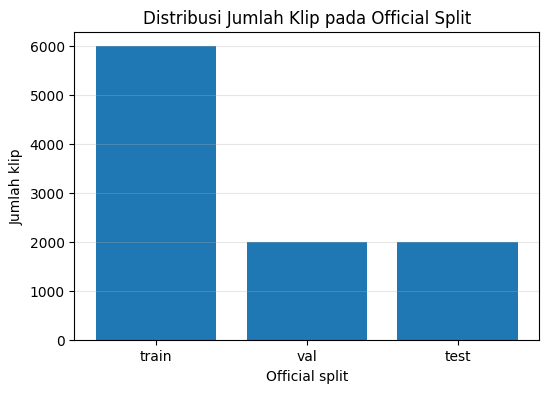

In [10]:
# =========================
# CELL 10: OFFICIAL SPLIT DISTRIBUTION
# =========================

split_counts = df_meta["split_official"].value_counts().rename_axis("split_official").reset_index(name="count")
split_counts["proportion"] = split_counts["count"] / split_counts["count"].sum()

display(split_counts)
save_table(split_counts, "official_split_distribution.csv")

plt.figure(figsize=(6, 4))
plt.bar(split_counts["split_official"], split_counts["count"])
plt.title("Distribusi Jumlah Klip pada Official Split")
plt.xlabel("Official split")
plt.ylabel("Jumlah klip")
plt.grid(axis="y", alpha=0.3)
save_fig("official_split_distribution.png")
plt.show()

In [11]:
# =========================
# CELL 11: BIG FIVE LABEL STATISTICS
# =========================

label_stats = df_meta[TRAIT_COLS].describe().T
label_stats["median"] = df_meta[TRAIT_COLS].median()
label_stats = label_stats[["count", "mean", "std", "min", "25%", "median", "50%", "75%", "max"]]
label_stats = label_stats.rename(columns={
    "25%": "q1",
    "50%": "q2",
    "75%": "q3",
})

display(label_stats)
save_table(label_stats.reset_index().rename(columns={"index": "trait"}), "bigfive_label_statistics.csv")

,count,mean,std,min,q1,median,q2,q3,max
extraversion,10000.0,0.476636,0.151005,0.0,0.373832,0.476636,0.476636,0.579439,1.0
neuroticism,10000.0,0.520833,0.152766,0.0,0.416667,0.531250,0.531250,0.635417,1.0
agreeableness,10000.0,0.549451,0.134057,0.0,0.461538,0.560440,0.560440,0.637363,1.0
conscientiousness,10000.0,0.524272,0.154804,0.0,0.417476,0.524272,0.524272,0.640777,1.0
openness,10000.0,0.566667,0.145812,0.0,0.466667,0.566667,0.566667,0.666667,1.0


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\bigfive_label_statistics.csv


WindowsPath('e:/tugas-akhir-qiqi/code/V2/output/tables/bigfive_label_statistics.csv')

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\bigfive_boxplot.png


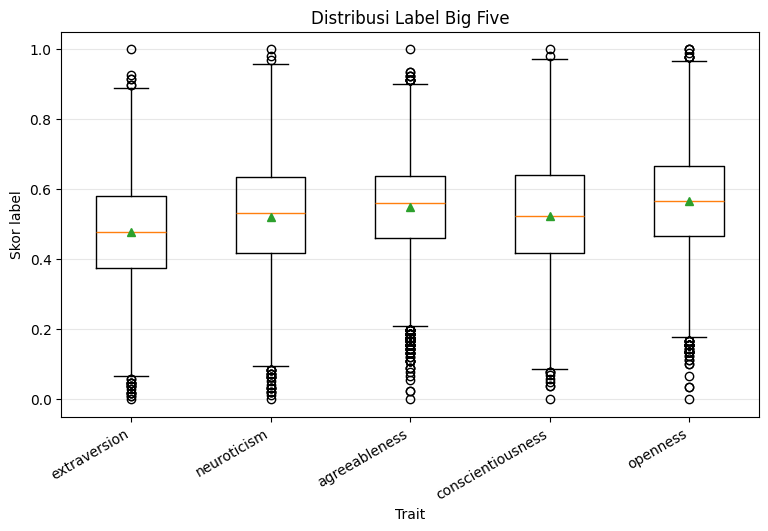

In [12]:
# =========================
# CELL 12: BIG FIVE BOXPLOT
# =========================

plt.figure(figsize=(9, 5))
plt.boxplot([df_meta[col].dropna() for col in TRAIT_COLS], labels=TRAIT_COLS, showmeans=True)
plt.title("Distribusi Label Big Five")
plt.xlabel("Trait")
plt.ylabel("Skor label")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
save_fig("bigfive_boxplot.png")
plt.show()

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\histogram_extraversion.png


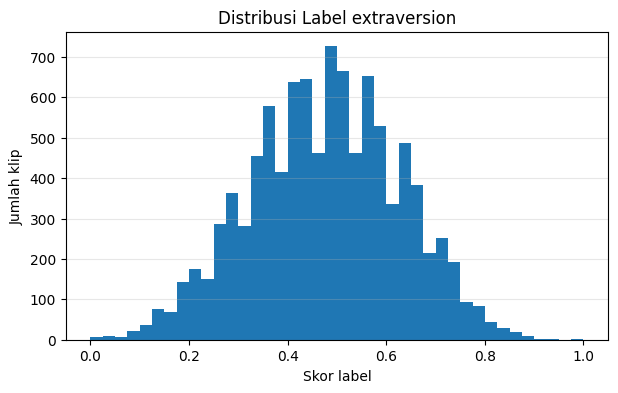

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\histogram_neuroticism.png


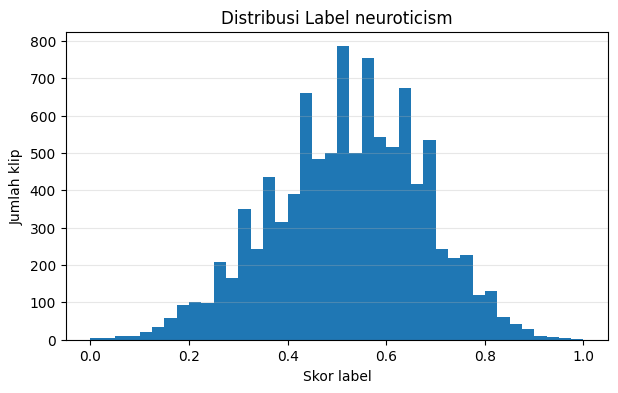

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\histogram_agreeableness.png


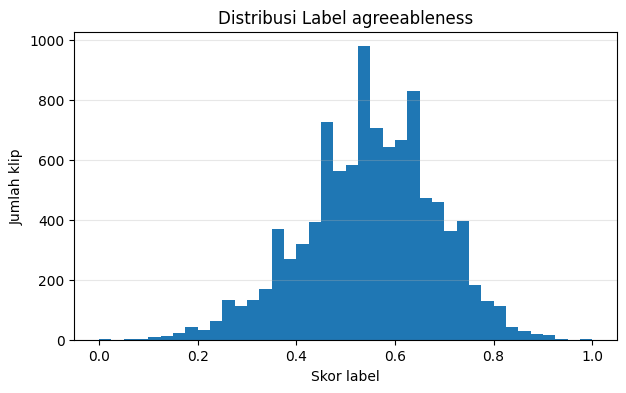

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\histogram_conscientiousness.png


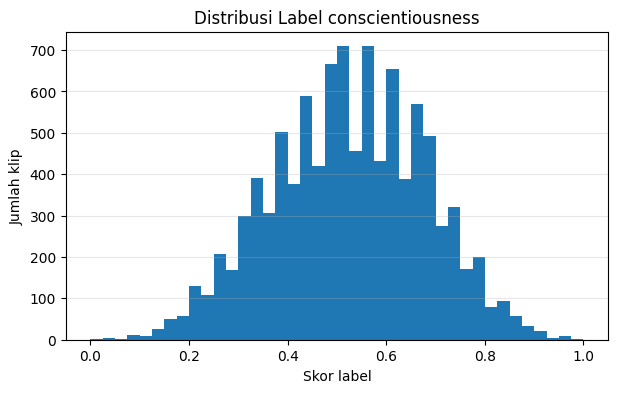

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\histogram_openness.png


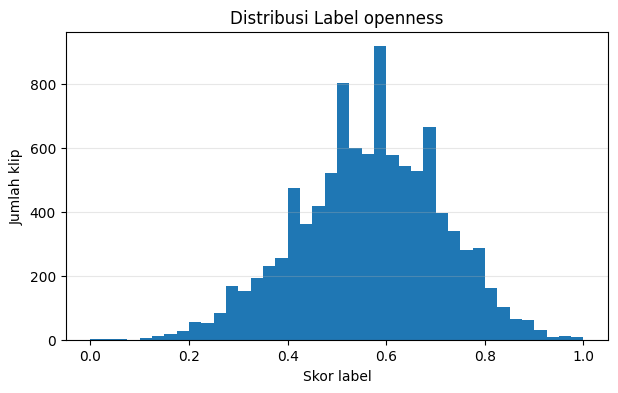

In [13]:
# =========================
# CELL 13: BIG FIVE HISTOGRAMS
# =========================

for trait in TRAIT_COLS:
    plt.figure(figsize=(7, 4))
    plt.hist(df_meta[trait].dropna(), bins=40)
    plt.title(f"Distribusi Label {trait}")
    plt.xlabel("Skor label")
    plt.ylabel("Jumlah klip")
    plt.grid(axis="y", alpha=0.3)
    save_fig(f"histogram_{trait}.png")
    plt.show()

,extraversion,neuroticism,agreeableness,conscientiousness,openness
extraversion,1.000000,0.794667,0.702498,0.575960,0.771288
neuroticism,0.794667,1.000000,0.726833,0.713806,0.769634
agreeableness,0.702498,0.726833,1.000000,0.652552,0.640596
conscientiousness,0.575960,0.713806,0.652552,1.000000,0.568710
openness,0.771288,0.769634,0.640596,0.568710,1.000000


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\bigfive_correlation_matrix.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\bigfive_correlation_heatmap.png


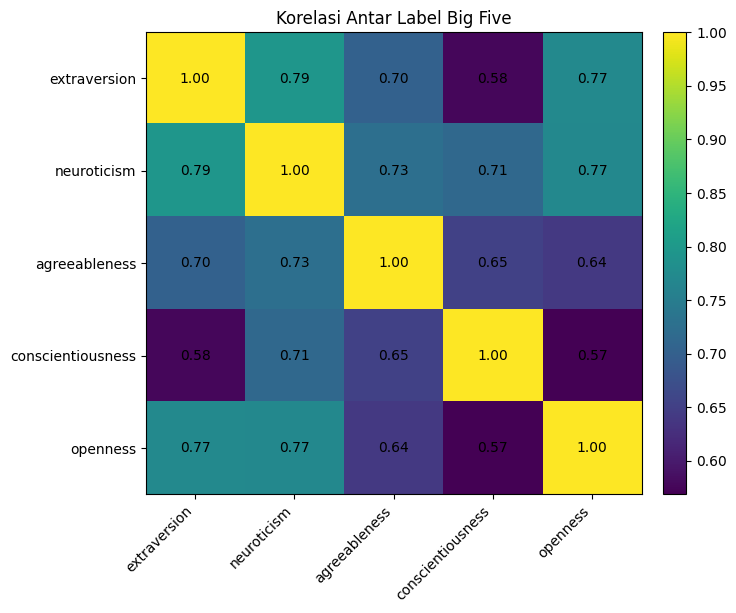

In [14]:
# =========================
# CELL 14: BIG FIVE CORRELATION HEATMAP
# =========================

corr = df_meta[TRAIT_COLS].corr()

display(corr)
save_table(corr.reset_index().rename(columns={"index": "trait"}), "bigfive_correlation_matrix.csv")

plt.figure(figsize=(7, 6))
im = plt.imshow(corr, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(TRAIT_COLS)), TRAIT_COLS, rotation=45, ha="right")
plt.yticks(range(len(TRAIT_COLS)), TRAIT_COLS)
plt.title("Korelasi Antar Label Big Five")

for i in range(len(TRAIT_COLS)):
    for j in range(len(TRAIT_COLS)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

save_fig("bigfive_correlation_heatmap.png")
plt.show()

,count,mean,std,min,25%,50%,75%,max
avg_trait,10000.0,0.527572,0.128212,0.049752,0.444584,0.534115,0.618499,0.923902


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\avg_trait_statistics.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\avg_trait_distribution.png


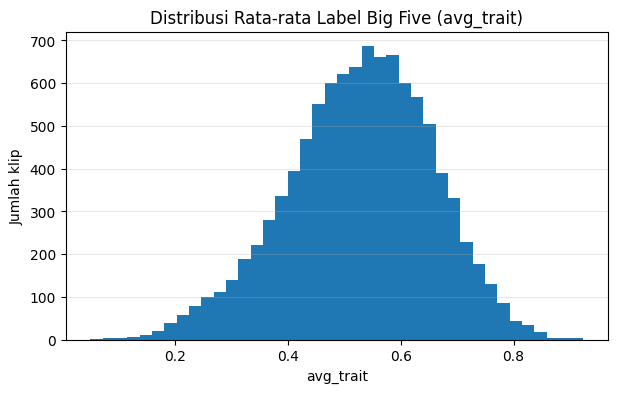

In [15]:
# =========================
# CELL 15: AVG_TRAIT DISTRIBUTION
# =========================

avg_trait_stats = df_meta["avg_trait"].describe().to_frame(name="avg_trait").T
display(avg_trait_stats)
save_table(avg_trait_stats.reset_index().rename(columns={"index": "variable"}), "avg_trait_statistics.csv")

plt.figure(figsize=(7, 4))
plt.hist(df_meta["avg_trait"].dropna(), bins=40)
plt.title("Distribusi Rata-rata Label Big Five (avg_trait)")
plt.xlabel("avg_trait")
plt.ylabel("Jumlah klip")
plt.grid(axis="y", alpha=0.3)
save_fig("avg_trait_distribution.png")
plt.show()

extraversion                               neuroticism  \
                       mean       std       min       max        mean   
split_official                                                          
test               0.477925  0.150149  0.009346  0.897196    0.521745   
train              0.476146  0.152297  0.000000  0.925234    0.520286   
val                0.476813  0.148001  0.018692  1.000000    0.521563   

                                             agreeableness            \
                     std       min       max          mean       std   
split_official                                                         
test            0.153327  0.010417  1.000000      0.551659  0.133358   
train           0.153546  0.020833  0.979167      0.548181  0.136385   
val             0.149901  0.000000  0.968750      0.551049  0.127571   

                                   conscientiousness                      \
                     min       max              mean       std       min   
split_official                                                             
test            0.109890  0.923077          0.525146  0.152633  0.087379   
train           0.000000  1.000000          0.522731  0.155219  0.000000   
val             0.021978  0.934066          0.528019  0.155717  0.097087   

                          openness                                
                     max      mean       std       min       max  
split_official                                                    
test            0.980583  0.568172  0.144682  0.100000  0.977778  
train           0.970874  0.566281  0.146990  0.000000  1.000000  
val             1.000000  0.566317  0.143433  0.033333  1.000000

Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\trait_statistics_per_official_split.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\extraversion_by_official_split_boxplot.png


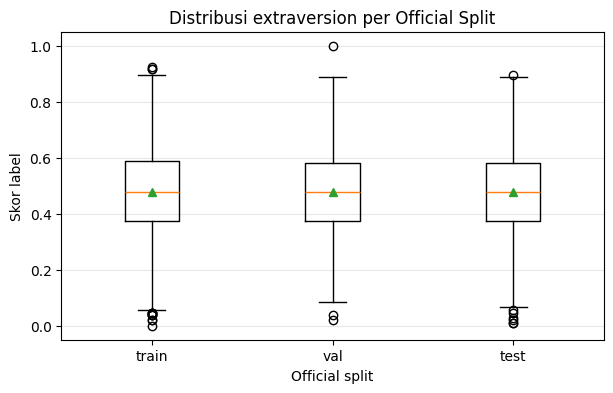

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\neuroticism_by_official_split_boxplot.png


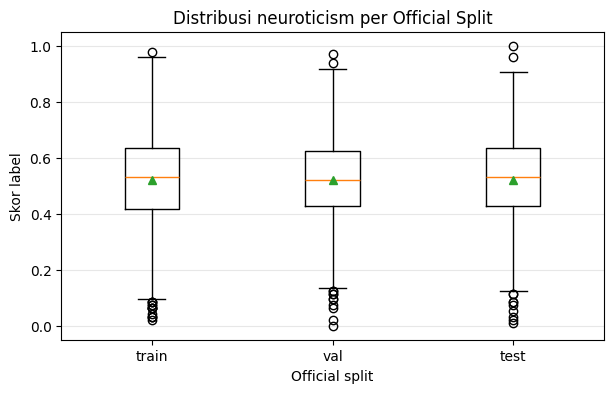

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\agreeableness_by_official_split_boxplot.png


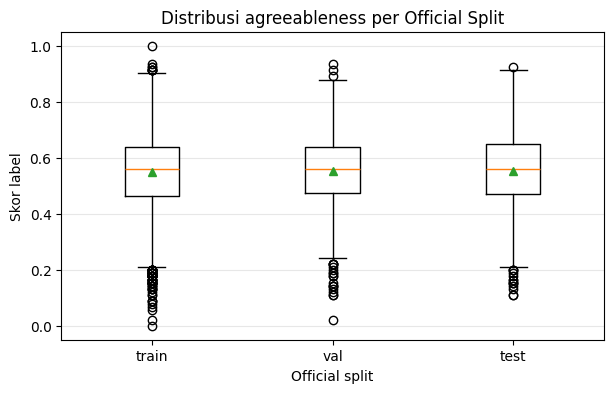

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\conscientiousness_by_official_split_boxplot.png


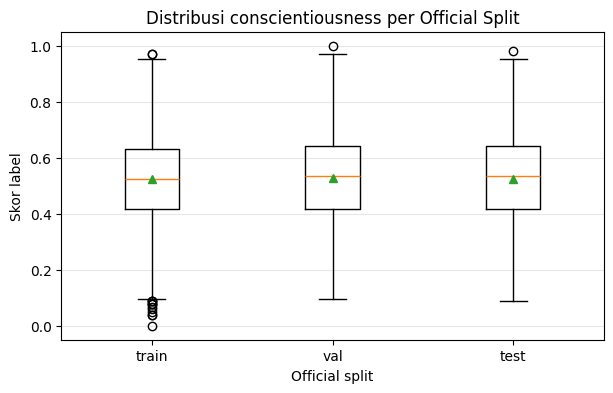

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\openness_by_official_split_boxplot.png


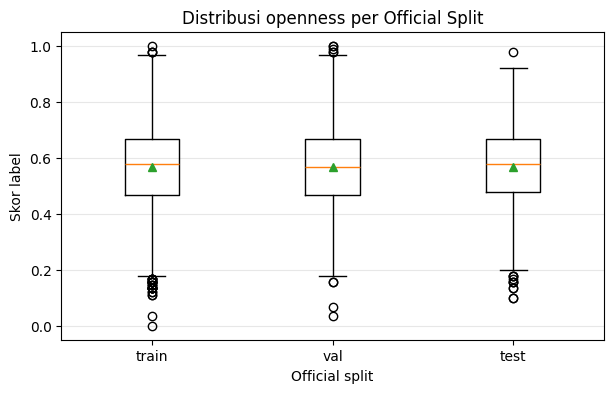

In [16]:
# =========================
# CELL 16: TRAIT DISTRIBUTION PER OFFICIAL SPLIT
# =========================

split_trait_stats = (
    df_meta
    .groupby("split_official")[TRAIT_COLS]
    .agg(["mean", "std", "min", "max"])
)

display(split_trait_stats)
save_table(split_trait_stats.reset_index(), "trait_statistics_per_official_split.csv")

for trait in TRAIT_COLS:
    plt.figure(figsize=(7, 4))
    data = [
        df_meta.loc[df_meta["split_official"] == split, trait].dropna()
        for split in ["train", "val", "test"]
        if split in df_meta["split_official"].unique()
    ]
    labels = [
        split for split in ["train", "val", "test"]
        if split in df_meta["split_official"].unique()
    ]

    plt.boxplot(data, labels=labels, showmeans=True)
    plt.title(f"Distribusi {trait} per Official Split")
    plt.xlabel("Official split")
    plt.ylabel("Skor label")
    plt.grid(axis="y", alpha=0.3)
    save_fig(f"{trait}_by_official_split_boxplot.png")
    plt.show()

,gender,count,proportion
0,2,5462,0.5462
1,1,4538,0.4538


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\gender_distribution.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\gender_distribution.png


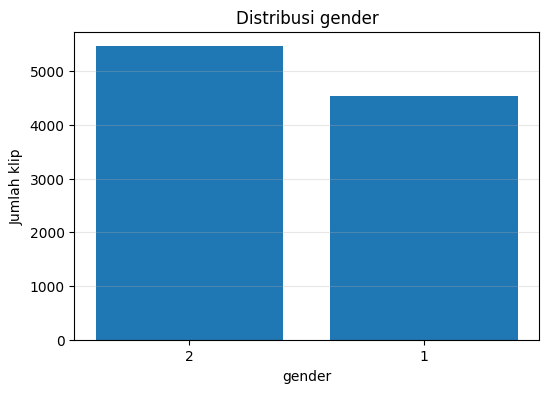

,ethnicity,count,proportion
0,2,8598,0.8598
1,3,1071,0.1071
2,1,331,0.0331


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\ethnicity_distribution.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\ethnicity_distribution.png


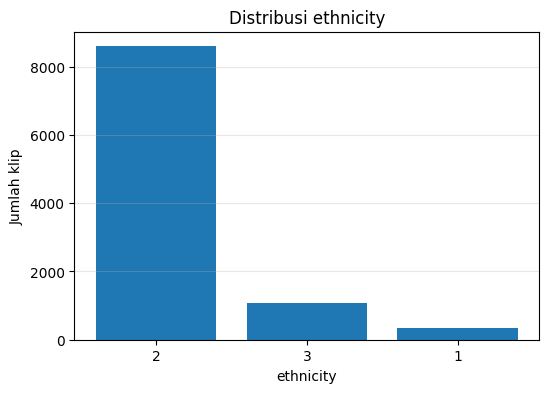

,age_group,count,proportion
0,5,4908,0.4908
1,6,2344,0.2344
2,4,1960,0.1960
3,7,413,0.0413
4,3,250,0.0250
5,8,105,0.0105
6,2,18,0.0018
7,1,2,0.0002


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\age_group_distribution.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\age_group_distribution.png


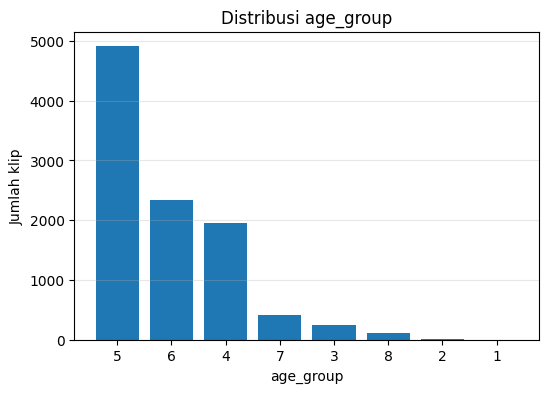

In [17]:
# =========================
# CELL 17: DEMOGRAPHIC DISTRIBUTION
# =========================

demographic_tables = {}

for col in META_COLS:
    if col in df_meta.columns:
        dist = df_meta[col].value_counts(dropna=False).rename_axis(col).reset_index(name="count")
        dist["proportion"] = dist["count"] / dist["count"].sum()
        demographic_tables[col] = dist

        display(dist)
        save_table(dist, f"{col}_distribution.csv")

        plt.figure(figsize=(6, 4))
        plt.bar(dist[col].astype(str), dist["count"])
        plt.title(f"Distribusi {col}")
        plt.xlabel(col)
        plt.ylabel("Jumlah klip")
        plt.grid(axis="y", alpha=0.3)
        save_fig(f"{col}_distribution.png")
        plt.show()
    else:
        print(f"Kolom {col} tidak ditemukan.")

,gender,ethnicity,count,proportion
0,1,1,96,0.0096
1,1,2,4104,0.4104
2,1,3,338,0.0338
3,2,1,235,0.0235
4,2,2,4494,0.4494
5,2,3,733,0.0733


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\gender_ethnicity_distribution.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\gender_ethnicity_heatmap.png


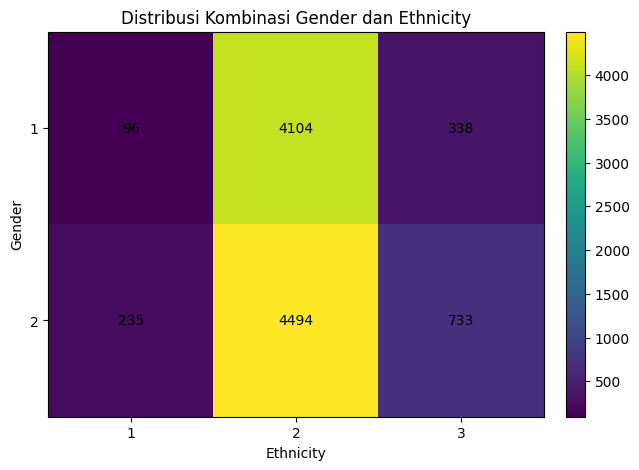

In [18]:
# =========================
# CELL 18: GENDER x ETHNICITY DISTRIBUTION
# =========================

if "gender" in df_meta.columns and "ethnicity" in df_meta.columns:
    gender_ethnicity = (
        df_meta
        .groupby(["gender", "ethnicity"])
        .size()
        .reset_index(name="count")
    )
    gender_ethnicity["proportion"] = gender_ethnicity["count"] / gender_ethnicity["count"].sum()

    display(gender_ethnicity)
    save_table(gender_ethnicity, "gender_ethnicity_distribution.csv")

    pivot_ge = gender_ethnicity.pivot(index="gender", columns="ethnicity", values="count").fillna(0)

    plt.figure(figsize=(7, 5))
    im = plt.imshow(pivot_ge.values, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(pivot_ge.columns)), pivot_ge.columns.astype(str))
    plt.yticks(range(len(pivot_ge.index)), pivot_ge.index.astype(str))
    plt.title("Distribusi Kombinasi Gender dan Ethnicity")
    plt.xlabel("Ethnicity")
    plt.ylabel("Gender")

    for i in range(pivot_ge.shape[0]):
        for j in range(pivot_ge.shape[1]):
            plt.text(j, i, int(pivot_ge.iloc[i, j]), ha="center", va="center")

    save_fig("gender_ethnicity_heatmap.png")
    plt.show()
else:
    print("Kolom gender atau ethnicity tidak ditemukan.")

In [19]:
# =========================
# CELL 19: AUDIO PATH CONSTRUCTION AND AVAILABILITY CHECK
# =========================

df_meta["audio_path"] = df_meta["clip_id"].astype(str).apply(lambda x: AUDIO_DIR / f"{x}.wav")
df_meta["audio_exists"] = df_meta["audio_path"].apply(lambda p: p.exists())

audio_availability = pd.DataFrame([
    {
        "komponen": "Jumlah metadata",
        "nilai": len(df_meta),
    },
    {
        "komponen": "Audio ditemukan",
        "nilai": int(df_meta["audio_exists"].sum()),
    },
    {
        "komponen": "Audio tidak ditemukan",
        "nilai": int((~df_meta["audio_exists"]).sum()),
    },
    {
        "komponen": "Rasio audio ditemukan",
        "nilai": float(df_meta["audio_exists"].mean()),
    },
])

display(audio_availability)
save_table(audio_availability, "audio_availability_summary.csv")

missing_audio = df_meta.loc[~df_meta["audio_exists"], ["clip_id", "audio_path"]].copy()
display(missing_audio.head())
save_table(missing_audio, "missing_audio_files.csv")

,komponen,nilai
0,Jumlah metadata,10000.0
1,Audio ditemukan,10000.0
2,Audio tidak ditemukan,0.0
3,Rasio audio ditemukan,1.0


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\audio_availability_summary.csv


,clip_id,audio_path


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\missing_audio_files.csv


WindowsPath('e:/tugas-akhir-qiqi/code/V2/output/tables/missing_audio_files.csv')

,clip_id,split_official,duration_sec,audio_path
0,--Ymqszjv54.001,train,15.0,E:\tugas-akhir-qiqi\output\preprocessing\prepr...
1,--Ymqszjv54.003,train,15.0,E:\tugas-akhir-qiqi\output\preprocessing\prepr...
2,--Ymqszjv54.004,train,15.0,E:\tugas-akhir-qiqi\output\preprocessing\prepr...
3,--Ymqszjv54.005,train,15.0,E:\tugas-akhir-qiqi\output\preprocessing\prepr...
4,-2qsCrkXdWs.001,train,15.0,E:\tugas-akhir-qiqi\output\preprocessing\prepr...


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\audio_duration_per_clip.csv


,count,mean,std,min,25%,50%,75%,max
duration_sec,10000.0,15.0,0.0,15.0,15.0,15.0,15.0,15.0


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\audio_duration_statistics.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\audio_duration_distribution.png


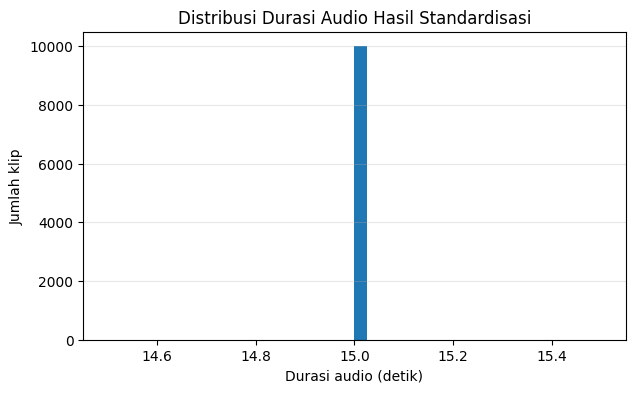

In [20]:
# =========================
# CELL 20: AUDIO DURATION ANALYSIS
# =========================

if HAS_LIBROSA:
    audio_rows = []

    existing_audio_df = df_meta[df_meta["audio_exists"]].copy()

    for i, row in existing_audio_df.iterrows():
        path = row["audio_path"]

        try:
            duration = librosa.get_duration(path=str(path))
            audio_rows.append({
                "clip_id": row["clip_id"],
                "split_official": row["split_official"],
                "duration_sec": duration,
                "audio_path": str(path),
            })
        except Exception as e:
            audio_rows.append({
                "clip_id": row["clip_id"],
                "split_official": row["split_official"],
                "duration_sec": np.nan,
                "audio_path": str(path),
            })

    df_audio_duration = pd.DataFrame(audio_rows)

    display(df_audio_duration.head())
    save_table(df_audio_duration, "audio_duration_per_clip.csv")

    audio_duration_stats = df_audio_duration["duration_sec"].describe().to_frame(name="duration_sec").T
    display(audio_duration_stats)
    save_table(audio_duration_stats.reset_index().rename(columns={"index": "variable"}), "audio_duration_statistics.csv")

    plt.figure(figsize=(7, 4))
    plt.hist(df_audio_duration["duration_sec"].dropna(), bins=40)
    plt.title("Distribusi Durasi Audio Hasil Standardisasi")
    plt.xlabel("Durasi audio (detik)")
    plt.ylabel("Jumlah klip")
    plt.grid(axis="y", alpha=0.3)
    save_fig("audio_duration_distribution.png")
    plt.show()

else:
    print("librosa tidak tersedia. Analisis durasi audio dilewati.")

In [21]:
# =========================
# CELL 21: LOAD VAD REPORT AND DROP LIST
# =========================

df_vad = None
df_vad_drop = None

if VAD_REPORT_PATH.exists():
    df_vad = pd.read_csv(VAD_REPORT_PATH)
    print("VAD report loaded:", df_vad.shape)
    display(df_vad.head())
    save_table(df_vad.head(20), "vad_report_preview.csv")
else:
    print("vad_report.csv tidak ditemukan.")

if VAD_DROP_PATH.exists():
    df_vad_drop = pd.read_csv(VAD_DROP_PATH)
    print("VAD drop loaded:", df_vad_drop.shape)
    display(df_vad_drop.head())
    save_table(df_vad_drop, "vad_drop.csv")
else:
    print("vad_drop.csv tidak ditemukan.")

VAD report loaded: (10000, 4)


,clip_id,speech_sec,voiced_ratio,n_seg
0,--Ymqszjv54.001,12.418,0.827867,6
1,--Ymqszjv54.003,11.036,0.735733,8
2,--Ymqszjv54.004,9.768,0.651200,6
3,--Ymqszjv54.005,10.392,0.692800,9
4,-2qsCrkXdWs.001,13.434,0.895600,8


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\vad_report_preview.csv
VAD drop loaded: (26, 5)


,clip_id,speech_sec,voiced_ratio,n_seg,reason
0,521sm7CTyfg.000,0.668,0.044533,1,too_little_speech
1,KRo-x2uoHUg.003,0.000,0.000000,0,too_little_speech
2,Lz3hYPF6aIM.000,0.220,0.014667,1,too_little_speech
3,OXkDmd3nA94.000,0.888,0.059200,2,too_little_speech
4,OXkDmd3nA94.002,0.440,0.029333,2,too_little_speech


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\vad_drop.csv


,count,mean,std,min,25%,50%,75%,max
speech_sec,10000.0,13.118778,1.844391,0.0,12.4860,13.612000,14.350000,15.0
voiced_ratio,10000.0,0.874585,0.122959,0.0,0.8324,0.907467,0.956667,1.0
n_seg,10000.0,4.289200,1.931201,0.0,3.0000,4.000000,6.000000,13.0


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\vad_statistics.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\vad_speech_sec_distribution.png


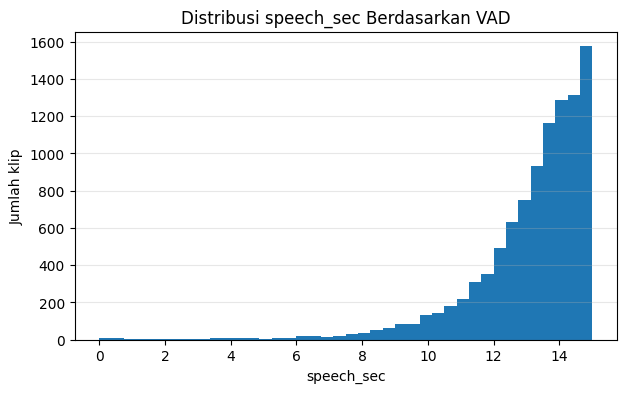

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\vad_voiced_ratio_distribution.png


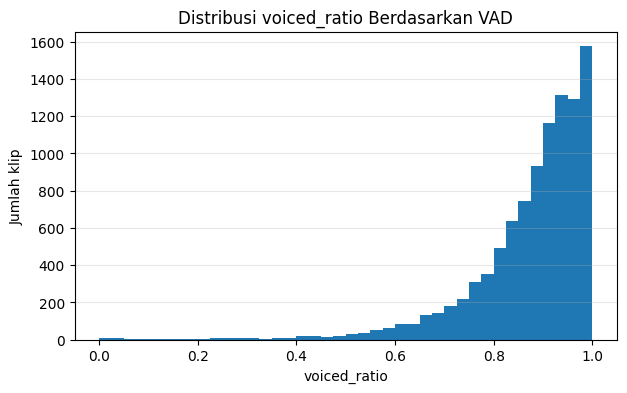

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\vad_n_seg_distribution.png


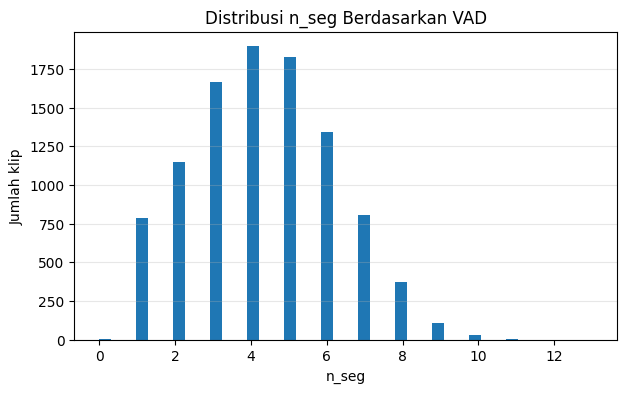

In [22]:
# =========================
# CELL 22: VAD STATISTICS
# =========================

if df_vad is not None:
    vad_numeric_cols = [col for col in ["speech_sec", "voiced_ratio", "n_seg"] if col in df_vad.columns]

    if vad_numeric_cols:
        vad_stats = df_vad[vad_numeric_cols].describe().T
        display(vad_stats)
        save_table(vad_stats.reset_index().rename(columns={"index": "metric"}), "vad_statistics.csv")

        for col in vad_numeric_cols:
            plt.figure(figsize=(7, 4))
            plt.hist(df_vad[col].dropna(), bins=40)
            plt.title(f"Distribusi {col} Berdasarkan VAD")
            plt.xlabel(col)
            plt.ylabel("Jumlah klip")
            plt.grid(axis="y", alpha=0.3)
            save_fig(f"vad_{col}_distribution.png")
            plt.show()
    else:
        print("Kolom speech_sec / voiced_ratio / n_seg tidak ditemukan pada vad_report.")
else:
    print("VAD report tidak tersedia.")

In [23]:
# =========================
# CELL 23: MERGE METADATA WITH VAD
# =========================

df_meta_vad = df_meta.copy()

if df_vad is not None and "clip_id" in df_vad.columns:
    vad_cols_to_merge = ["clip_id"] + [col for col in ["speech_sec", "voiced_ratio", "n_seg"] if col in df_vad.columns]
    df_meta_vad = df_meta_vad.merge(df_vad[vad_cols_to_merge], on="clip_id", how="left")

    print("df_meta_vad shape:", df_meta_vad.shape)
    display(df_meta_vad.head())

    save_table(df_meta_vad, "metadata_with_vad.csv")
else:
    print("VAD tidak digabung karena df_vad tidak tersedia atau tidak punya clip_id.")

df_meta_vad shape: (10000, 19)


,group_id,clip_id,split_official,video_name,ethnicity,gender,age_group,extraversion,neuroticism,agreeableness,conscientiousness,openness,interview,avg_trait,audio_path,audio_exists,speech_sec,voiced_ratio,n_seg
0,--Ymqszjv54,--Ymqszjv54.001,train,--Ymqszjv54.001.mp4,2,1,5,0.551402,0.500000,0.527473,0.650485,0.744444,0.588785,0.594761,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,True,12.418,0.827867,6
1,--Ymqszjv54,--Ymqszjv54.003,train,--Ymqszjv54.003.mp4,2,1,5,0.392523,0.427083,0.516484,0.475728,0.466667,0.392523,0.455697,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,True,11.036,0.735733,8
2,--Ymqszjv54,--Ymqszjv54.004,train,--Ymqszjv54.004.mp4,2,1,5,0.317757,0.322917,0.549451,0.368932,0.544444,0.401869,0.420700,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,True,9.768,0.651200,6
3,--Ymqszjv54,--Ymqszjv54.005,train,--Ymqszjv54.005.mp4,2,1,5,0.299065,0.291667,0.373626,0.320388,0.344444,0.280374,0.325838,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,True,10.392,0.692800,9
4,-2qsCrkXdWs,-2qsCrkXdWs.001,train,-2qsCrkXdWs.001.mp4,2,1,2,0.476636,0.604167,0.593407,0.572816,0.611111,0.560748,0.571627,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,True,13.434,0.895600,8


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\metadata_with_vad.csv


Saved audio figure: e:\tugas-akhir-qiqi\code\V2\output\audio_examples\example_normal_speech_FaBTYkzhuK4.000.png


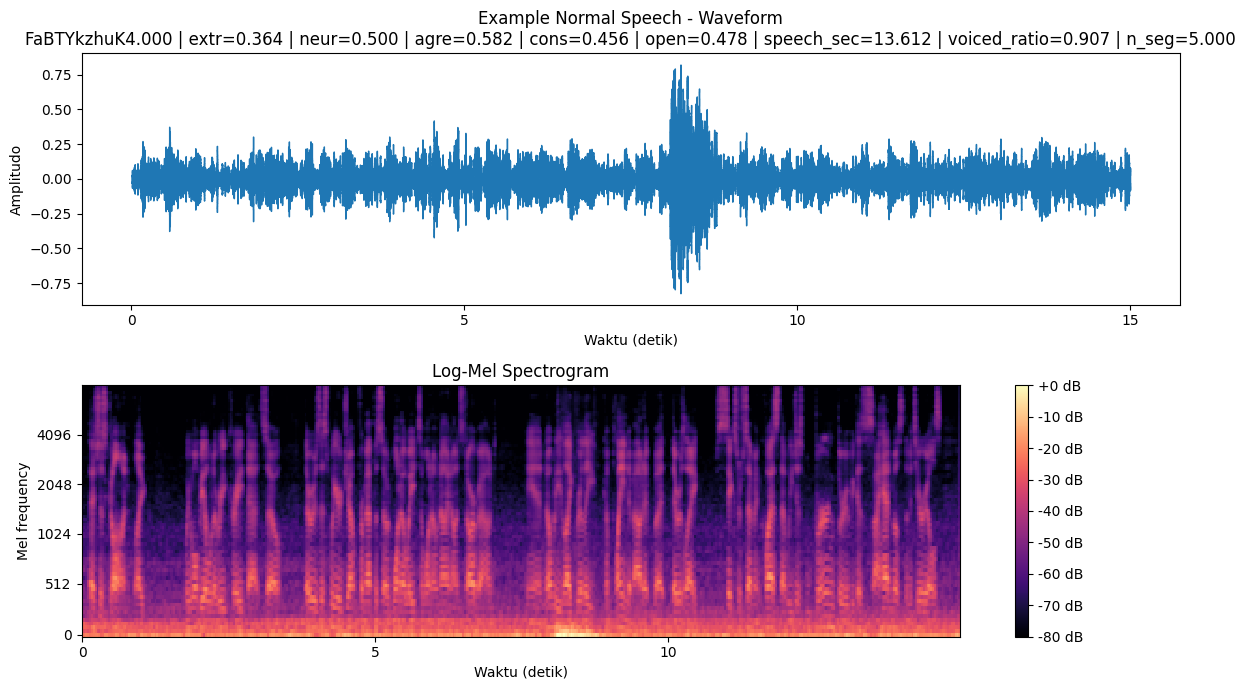

Saved audio figure: e:\tugas-akhir-qiqi\code\V2\output\audio_examples\example_high_speech_-VTqcHNgH7M.004.png


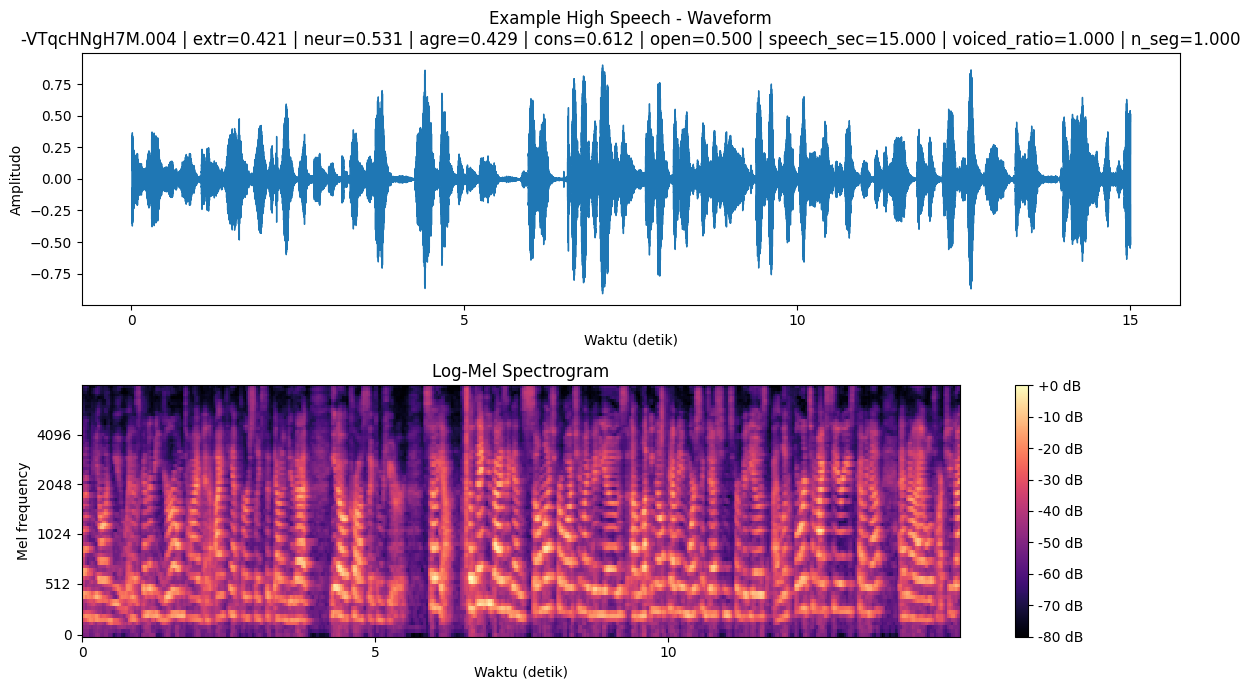

Saved audio figure: e:\tugas-akhir-qiqi\code\V2\output\audio_examples\example_low_speech_KRo-x2uoHUg.003.png


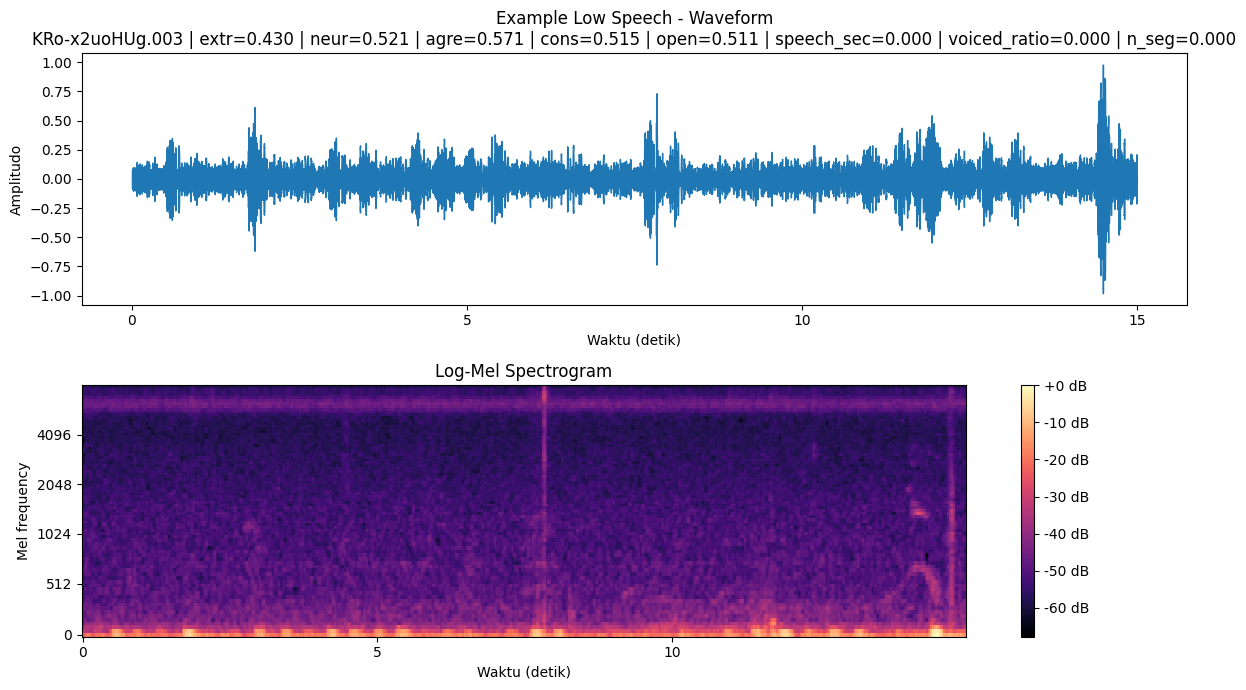

Saved audio figure: e:\tugas-akhir-qiqi\code\V2\output\audio_examples\example_low_avg_trait_2DZb5yIc6Fg.005.png


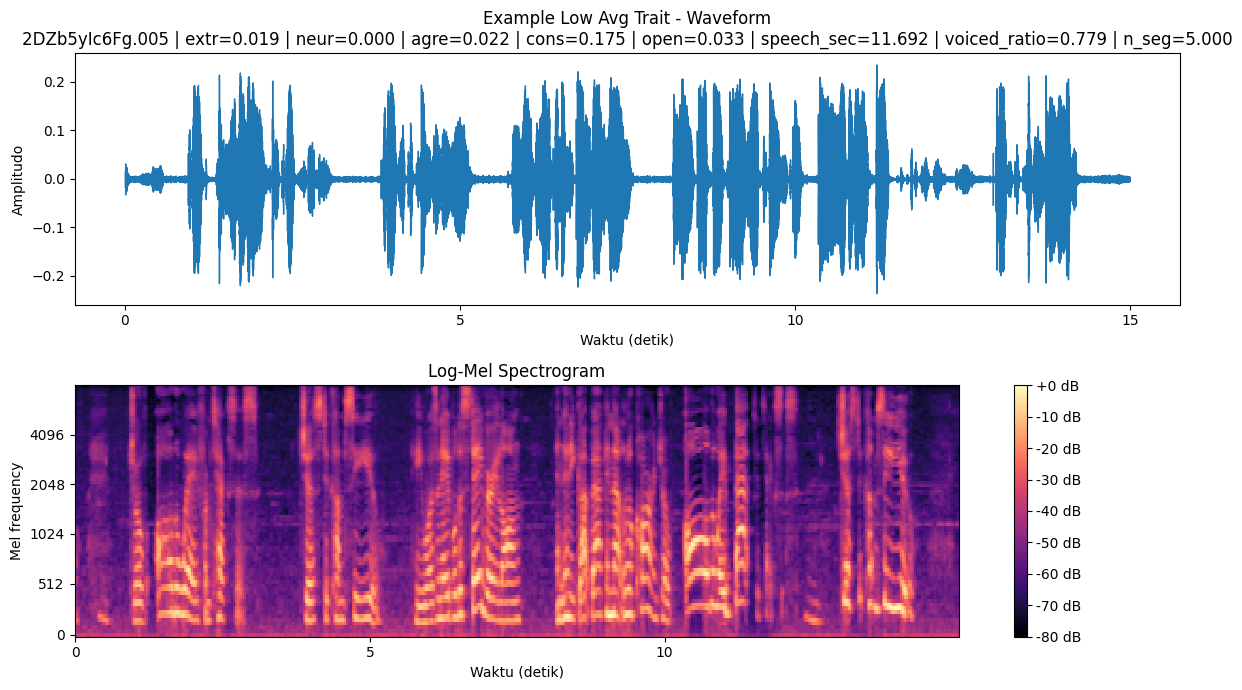

Saved audio figure: e:\tugas-akhir-qiqi\code\V2\output\audio_examples\example_high_avg_trait_84emxO86qa8.005.png


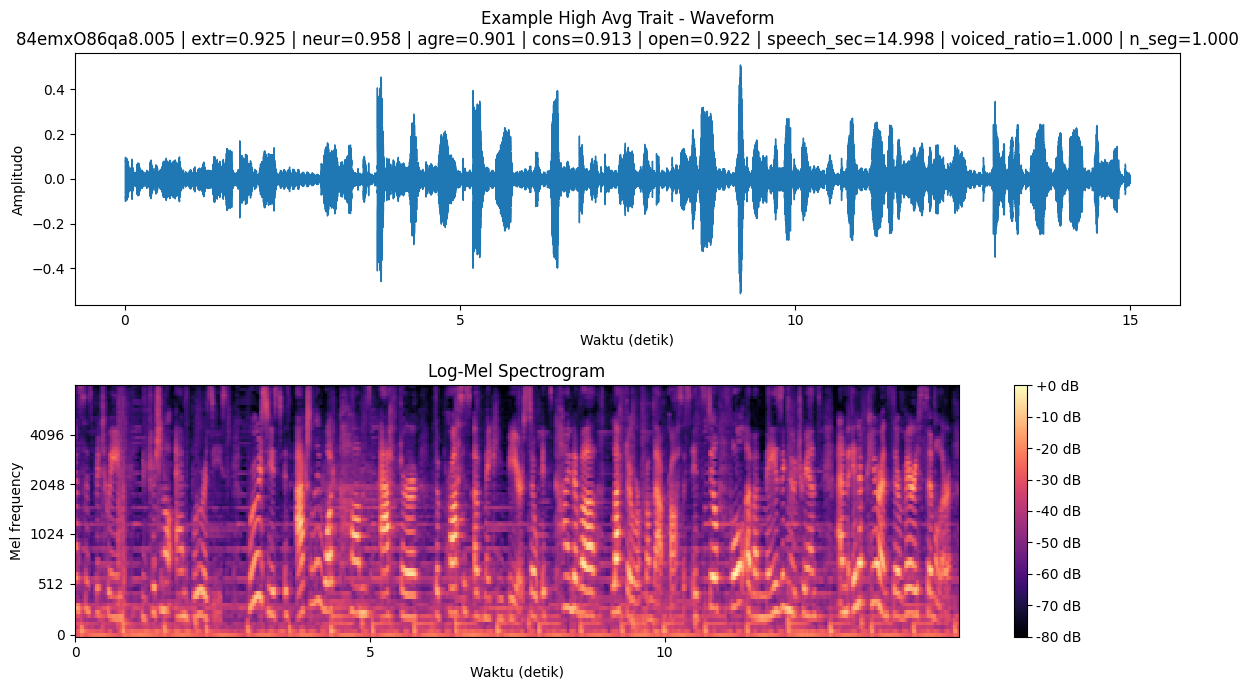

In [24]:
# =========================
# CELL 24: WAVEFORM AND LOG-MEL SPECTROGRAM EXAMPLES
# =========================

def plot_waveform_and_melspec(row, title_prefix):
    if not HAS_LIBROSA:
        print("librosa tidak tersedia.")
        return

    audio_path = row["audio_path"]

    if not Path(audio_path).exists():
        print("Audio tidak ditemukan:", audio_path)
        return

    y, sr = librosa.load(str(audio_path), sr=16000, mono=True)

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    label_text = " | ".join([f"{trait[:4]}={row[trait]:.3f}" for trait in TRAIT_COLS if trait in row.index])

    extra_info = []
    for col in ["speech_sec", "voiced_ratio", "n_seg"]:
        if col in row.index and pd.notna(row[col]):
            extra_info.append(f"{col}={row[col]:.3f}")

    extra_text = " | ".join(extra_info)

    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"{title_prefix} - Waveform\n{row['clip_id']} | {label_text} | {extra_text}")
    plt.xlabel("Waktu (detik)")
    plt.ylabel("Amplitudo")

    plt.subplot(2, 1, 2)
    librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel")
    plt.colorbar(format="%+2.0f dB")
    plt.title("Log-Mel Spectrogram")
    plt.xlabel("Waktu (detik)")
    plt.ylabel("Mel frequency")

    plt.tight_layout()
    save_audio_fig(f"{title_prefix.lower().replace(' ', '_')}_{row['clip_id']}.png")
    plt.show()


if HAS_LIBROSA:
    candidates = df_meta_vad[df_meta_vad["audio_exists"]].copy()

    selected_examples = []

    # Contoh normal: speech_sec mendekati median
    if "speech_sec" in candidates.columns and candidates["speech_sec"].notna().any():
        median_speech = candidates["speech_sec"].median()
        idx_normal = (candidates["speech_sec"] - median_speech).abs().idxmin()
        selected_examples.append(("Example Normal Speech", candidates.loc[idx_normal]))

        # Contoh high speech
        idx_high = candidates["speech_sec"].idxmax()
        selected_examples.append(("Example High Speech", candidates.loc[idx_high]))

        # Contoh low speech
        idx_low = candidates["speech_sec"].idxmin()
        selected_examples.append(("Example Low Speech", candidates.loc[idx_low]))
    else:
        selected_examples.append(("Example Audio", candidates.sample(1, random_state=42).iloc[0]))

    # Contoh avg_trait rendah dan tinggi
    idx_low_trait = candidates["avg_trait"].idxmin()
    idx_high_trait = candidates["avg_trait"].idxmax()
    selected_examples.append(("Example Low Avg Trait", candidates.loc[idx_low_trait]))
    selected_examples.append(("Example High Avg Trait", candidates.loc[idx_high_trait]))

    used_clip_ids = set()

    for title, row in selected_examples:
        if row["clip_id"] in used_clip_ids:
            continue
        used_clip_ids.add(row["clip_id"])
        plot_waveform_and_melspec(row, title)

else:
    print("librosa tidak tersedia. Visualisasi waveform/log-mel dilewati.")

In [25]:
# =========================
# CELL 25: LOAD EGEMAPS FEATURES
# =========================

df_egemaps_train = pd.read_csv(EGEMAPS_TRAIN_PATH)
df_egemaps_val = pd.read_csv(EGEMAPS_VAL_PATH)
df_egemaps_test = pd.read_csv(EGEMAPS_TEST_PATH)

df_egemaps_train["split_official"] = "train"
df_egemaps_val["split_official"] = "val"
df_egemaps_test["split_official"] = "test"

df_egemaps = pd.concat([df_egemaps_train, df_egemaps_val, df_egemaps_test], ignore_index=True)

display_shape_and_head(df_egemaps, "df_egemaps")

egemaps_feature_cols = [col for col in df_egemaps.columns if col not in ["clip_id", "split_official"]]

egemaps_summary = pd.DataFrame([
    {
        "representation": "eGeMAPS",
        "num_samples": len(df_egemaps),
        "num_features": len(egemaps_feature_cols),
        "has_clip_id": "clip_id" in df_egemaps.columns,
        "missing_values": int(df_egemaps[egemaps_feature_cols].isna().sum().sum()),
    }
])

display(egemaps_summary)
save_table(egemaps_summary, "egemaps_summary.csv")

df_egemaps shape: (9974, 90)


,clip_id,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp,split_official
0,--Ymqszjv54.001,25.507914,0.107146,23.763643,24.627512,27.339914,3.576271,205.201580,203.091580,18.975096,...,0.002184,0.329736,3.135424,2.076356,0.201290,0.147008,0.260323,0.316528,-16.340939,train
1,--Ymqszjv54.003,25.126215,0.113853,23.568083,24.617601,26.765774,3.197691,26.793823,22.513718,20.610909,...,0.004924,0.193464,2.535023,1.808439,0.251111,0.153534,0.293077,0.363252,-15.927992,train
2,--Ymqszjv54.004,25.574844,0.137020,23.395996,24.643763,26.983828,3.587832,82.578910,100.079430,36.169643,...,0.006146,0.263668,2.134757,1.472557,0.238182,0.202274,0.440476,0.467164,-16.922182,train
3,--Ymqszjv54.005,26.497402,0.164169,24.266638,26.239866,27.665936,3.399298,115.543070,145.908680,49.455418,...,0.004366,0.214379,2.668446,2.076356,0.187742,0.162058,0.273871,0.392130,-15.951823,train
4,-2qsCrkXdWs.001,35.444283,0.091620,32.832863,34.865074,38.305870,5.473007,95.905290,175.381500,21.909246,...,0.009242,0.096231,2.935290,1.674481,0.386800,0.398906,0.198750,0.168679,-25.522635,train


,representation,num_samples,num_features,has_clip_id,missing_values
0,eGeMAPS,9974,88,True,0


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\egemaps_summary.csv


WindowsPath('e:/tugas-akhir-qiqi/code/V2/output/tables/egemaps_summary.csv')

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_ratio
F0semitoneFrom27.5Hz_sma3nz_amean,9974.0,31.961473,5.034385,0.000000,27.958715,32.735883,36.065817,50.491000,0,0.0
F0semitoneFrom27.5Hz_sma3nz_stddevNorm,9974.0,0.150883,0.071817,0.000000,0.099603,0.133496,0.183821,0.600413,0,0.0
F0semitoneFrom27.5Hz_sma3nz_percentile20.0,9974.0,28.783909,5.608483,0.000000,24.388283,29.651126,33.628374,44.207210,0,0.0
F0semitoneFrom27.5Hz_sma3nz_percentile50.0,9974.0,31.467523,5.297793,0.000000,27.193255,32.565911,35.699095,55.227770,0,0.0
F0semitoneFrom27.5Hz_sma3nz_percentile80.0,9974.0,34.884189,5.508001,0.000000,30.870720,35.731147,38.859572,61.536293,0,0.0
F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,9974.0,6.100280,3.814906,0.000000,3.816873,5.156206,6.985059,39.063324,0,0.0
F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,9974.0,197.311290,147.822920,-28.750364,93.388070,153.351625,258.820028,1329.660800,0,0.0
F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,9974.0,274.703581,240.934698,0.000000,106.330897,184.349365,374.420225,1610.691000,0,0.0
F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,9974.0,90.705412,77.260131,-53.241070,37.697682,68.316763,117.894363,973.203400,0,0.0
F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,9974.0,131.021229,155.046772,0.000000,39.995214,80.759282,152.928268,1416.908100,0,0.0


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\egemaps_feature_statistics.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\egemaps_F0semitoneFrom27.5Hz_sma3nz_amean_distribution.png


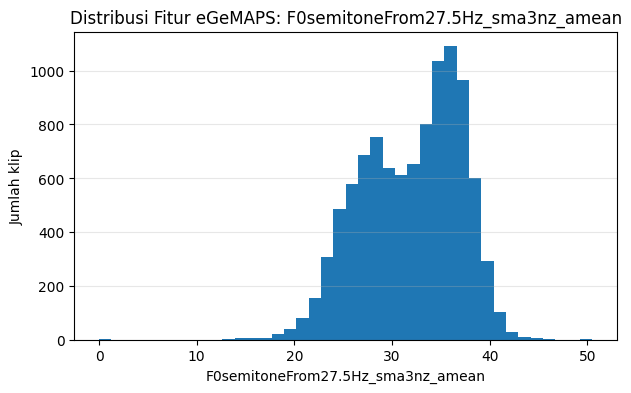

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\egemaps_loudness_sma3_amean_distribution.png


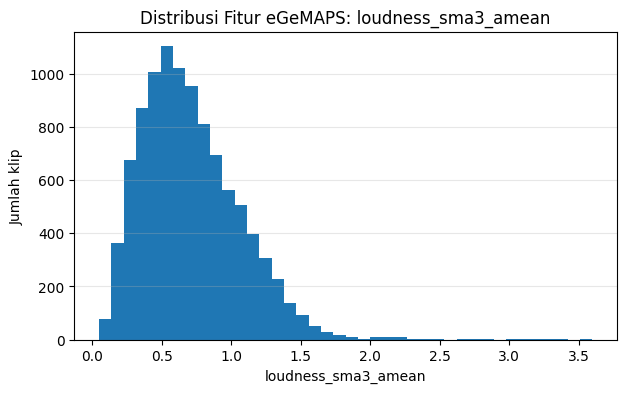

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\egemaps_spectralFlux_sma3_amean_distribution.png


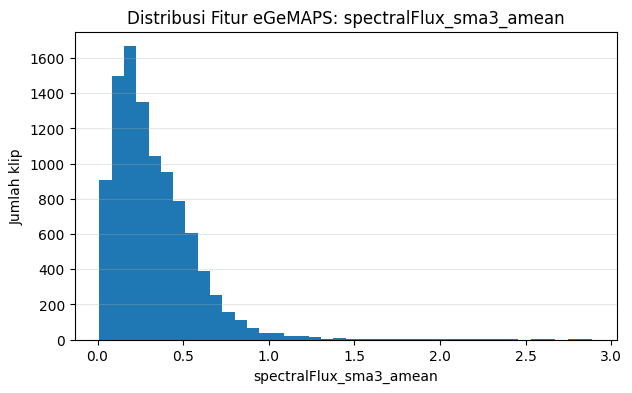

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\egemaps_jitterLocal_sma3nz_amean_distribution.png


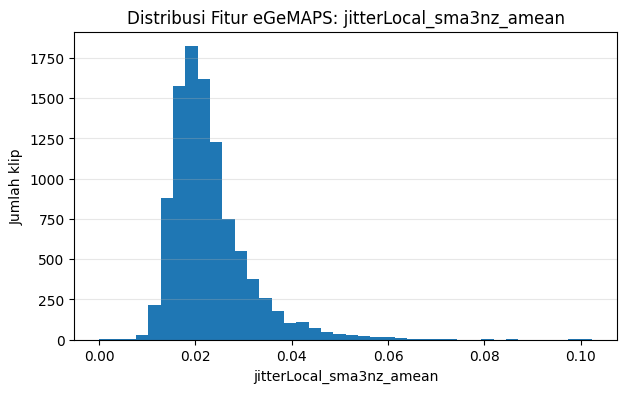

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\egemaps_shimmerLocaldB_sma3nz_amean_distribution.png


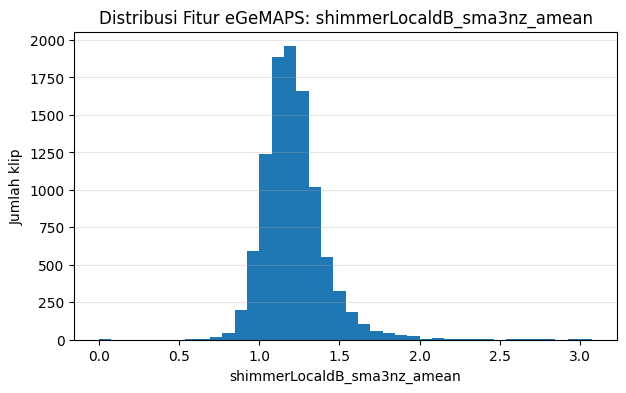

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\egemaps_HNRdBACF_sma3nz_amean_distribution.png


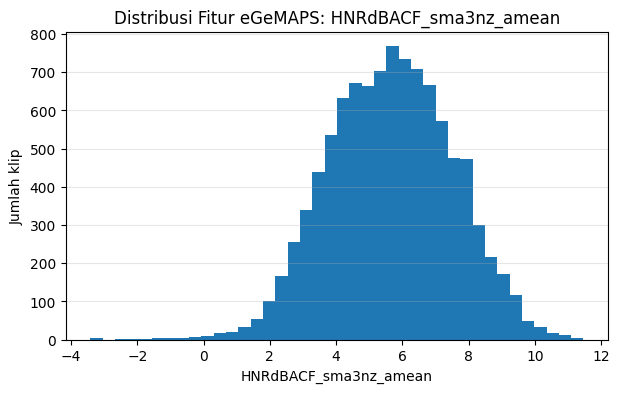

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\egemaps_VoicedSegmentsPerSec_distribution.png


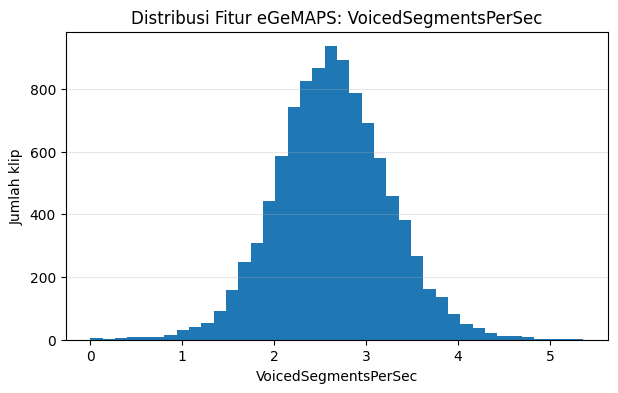

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\egemaps_MeanVoicedSegmentLengthSec_distribution.png


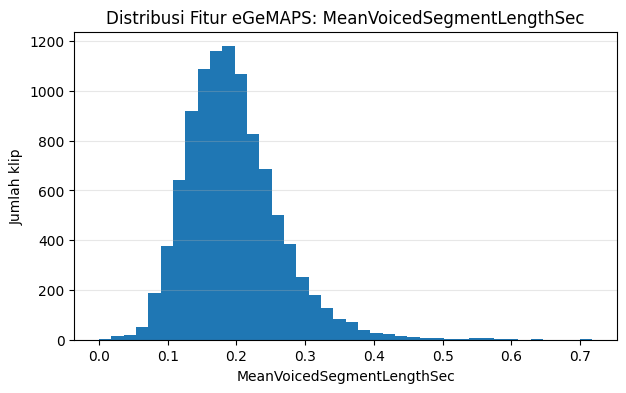

In [26]:
# =========================
# CELL 26: EGEMAPS FEATURE STATISTICS
# =========================

egemaps_stats = df_egemaps[egemaps_feature_cols].describe().T
egemaps_stats["missing_count"] = df_egemaps[egemaps_feature_cols].isna().sum()
egemaps_stats["missing_ratio"] = df_egemaps[egemaps_feature_cols].isna().mean()

display(egemaps_stats.head(20))
save_table(egemaps_stats.reset_index().rename(columns={"index": "feature"}), "egemaps_feature_statistics.csv")

# Plot beberapa fitur yang mudah diinterpretasikan
selected_egemaps_features = [
    "F0semitoneFrom27.5Hz_sma3nz_amean",
    "loudness_sma3_amean",
    "spectralFlux_sma3_amean",
    "jitterLocal_sma3nz_amean",
    "shimmerLocaldB_sma3nz_amean",
    "HNRdBACF_sma3nz_amean",
    "VoicedSegmentsPerSec",
    "MeanVoicedSegmentLengthSec",
]

selected_egemaps_features = [f for f in selected_egemaps_features if f in df_egemaps.columns]

for feature in selected_egemaps_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df_egemaps[feature].dropna(), bins=40)
    plt.title(f"Distribusi Fitur eGeMAPS: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Jumlah klip")
    plt.grid(axis="y", alpha=0.3)
    save_fig(f"egemaps_{feature}_distribution.png")
    plt.show()

In [27]:
# =========================
# CELL 27: LOAD SSL EMBEDDINGS
# =========================

def load_ssl_embedding(model_name, model_dir):
    model_dir = Path(model_dir)

    split_data = []

    for split in ["train", "val", "test"]:
        emb_path = model_dir / f"{split}_emb.npy"
        clip_path = model_dir / f"{split}_clip_id.csv"

        if not emb_path.exists() or not clip_path.exists():
            print(f"[{model_name}] Missing file for split {split}")
            continue

        emb = np.load(emb_path)
        clip_df = pd.read_csv(clip_path)

        # Cari kolom clip_id
        if "clip_id" not in clip_df.columns:
            if clip_df.shape[1] == 1:
                clip_df = clip_df.rename(columns={clip_df.columns[0]: "clip_id"})
            else:
                raise ValueError(f"{clip_path} tidak punya kolom clip_id dan jumlah kolom > 1.")

        if len(clip_df) != emb.shape[0]:
            raise ValueError(
                f"[{model_name} - {split}] Jumlah clip_id ({len(clip_df)}) tidak sama dengan embedding ({emb.shape[0]})."
            )

        split_data.append({
            "split": split,
            "embedding": emb,
            "clip_id": clip_df["clip_id"].astype(str).values,
        })

        print(f"[{model_name}] {split}: emb shape={emb.shape}, clip_id={len(clip_df)}")

    return split_data


ssl_embeddings = {}

for model_name, model_dir in SSL_DIRS.items():
    ssl_embeddings[model_name] = load_ssl_embedding(model_name, model_dir)

[hubert] train: emb shape=(5988, 768), clip_id=5988
[hubert] val: emb shape=(1994, 768), clip_id=1994
[hubert] test: emb shape=(1992, 768), clip_id=1992
[wav2vec2] train: emb shape=(5988, 768), clip_id=5988
[wav2vec2] val: emb shape=(1994, 768), clip_id=1994
[wav2vec2] test: emb shape=(1992, 768), clip_id=1992
[wavlm] train: emb shape=(5988, 768), clip_id=5988
[wavlm] val: emb shape=(1994, 768), clip_id=1994
[wavlm] test: emb shape=(1992, 768), clip_id=1992


In [28]:
# =========================
# CELL 28: SSL EMBEDDING SUMMARY
# =========================

embedding_summary_rows = []

for model_name, split_data in ssl_embeddings.items():
    for item in split_data:
        emb = item["embedding"]
        split = item["split"]

        embedding_summary_rows.append({
            "model": model_name,
            "split": split,
            "num_samples": emb.shape[0],
            "embedding_shape": str(emb.shape),
            "embedding_dim": emb.shape[1] if emb.ndim == 2 else np.nan,
            "has_nan": bool(np.isnan(emb).any()),
            "has_inf": bool(np.isinf(emb).any()),
        })

df_embedding_summary = pd.DataFrame(embedding_summary_rows)

display(df_embedding_summary)
save_table(df_embedding_summary, "ssl_embedding_summary.csv")

,model,split,num_samples,embedding_shape,embedding_dim,has_nan,has_inf
0,hubert,train,5988,"(5988, 768)",768,False,False
1,hubert,val,1994,"(1994, 768)",768,False,False
2,hubert,test,1992,"(1992, 768)",768,False,False
3,wav2vec2,train,5988,"(5988, 768)",768,False,False
4,wav2vec2,val,1994,"(1994, 768)",768,False,False
5,wav2vec2,test,1992,"(1992, 768)",768,False,False
6,wavlm,train,5988,"(5988, 768)",768,False,False
7,wavlm,val,1994,"(1994, 768)",768,False,False
8,wavlm,test,1992,"(1992, 768)",768,False,False


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\ssl_embedding_summary.csv


WindowsPath('e:/tugas-akhir-qiqi/code/V2/output/tables/ssl_embedding_summary.csv')

,model,split,clip_id,embedding_norm
0,hubert,train,--Ymqszjv54.001,4.427172
1,hubert,train,--Ymqszjv54.003,4.522365
2,hubert,train,--Ymqszjv54.004,4.500377
3,hubert,train,--Ymqszjv54.005,4.505160
4,hubert,train,-2qsCrkXdWs.001,4.111412


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\ssl_embedding_norms.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\hubert_embedding_norm_distribution.png


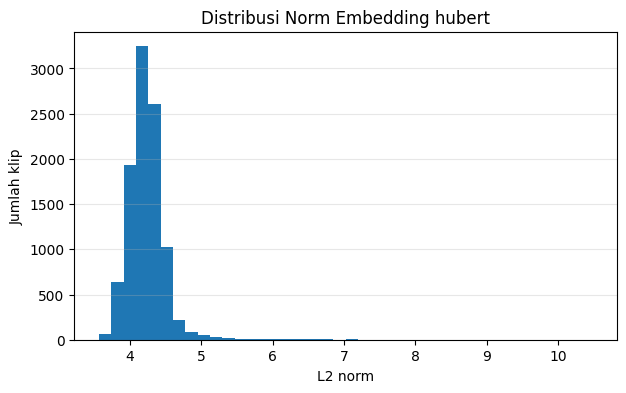

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\wav2vec2_embedding_norm_distribution.png


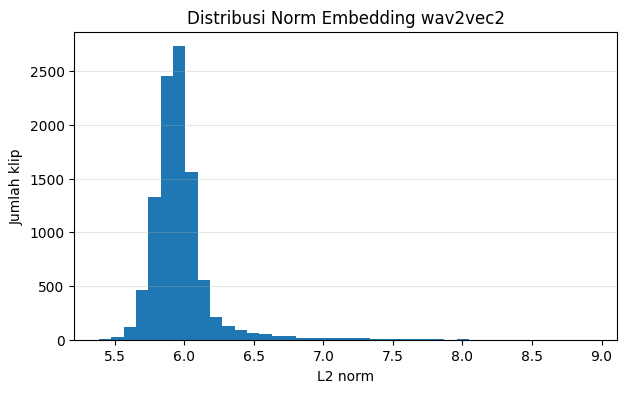

Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\wavlm_embedding_norm_distribution.png


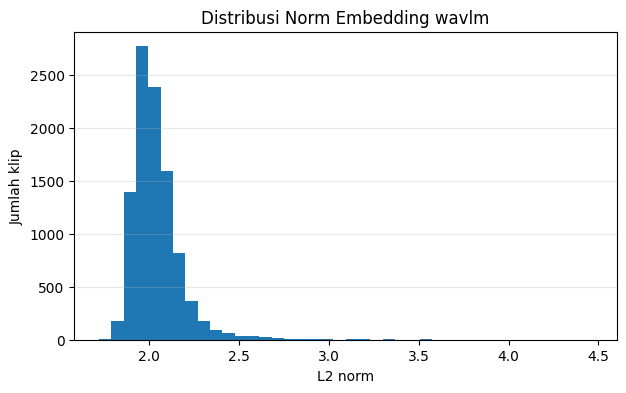

In [29]:
# =========================
# CELL 29: SSL EMBEDDING NORM DISTRIBUTION
# =========================

embedding_norm_rows = []

for model_name, split_data in ssl_embeddings.items():
    for item in split_data:
        split = item["split"]
        emb = item["embedding"]

        if emb.ndim != 2:
            print(f"[{model_name} - {split}] Embedding bukan 2D, dilewati.")
            continue

        norms = np.linalg.norm(emb, axis=1)

        for clip_id, norm_value in zip(item["clip_id"], norms):
            embedding_norm_rows.append({
                "model": model_name,
                "split": split,
                "clip_id": clip_id,
                "embedding_norm": norm_value,
            })

df_embedding_norm = pd.DataFrame(embedding_norm_rows)

display(df_embedding_norm.head())
save_table(df_embedding_norm, "ssl_embedding_norms.csv")

for model_name in df_embedding_norm["model"].unique():
    plt.figure(figsize=(7, 4))
    subset = df_embedding_norm[df_embedding_norm["model"] == model_name]
    plt.hist(subset["embedding_norm"].dropna(), bins=40)
    plt.title(f"Distribusi Norm Embedding {model_name}")
    plt.xlabel("L2 norm")
    plt.ylabel("Jumlah klip")
    plt.grid(axis="y", alpha=0.3)
    save_fig(f"{model_name}_embedding_norm_distribution.png")
    plt.show()

Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\hubert_pca_2d.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\hubert_embedding_pca_2d.png


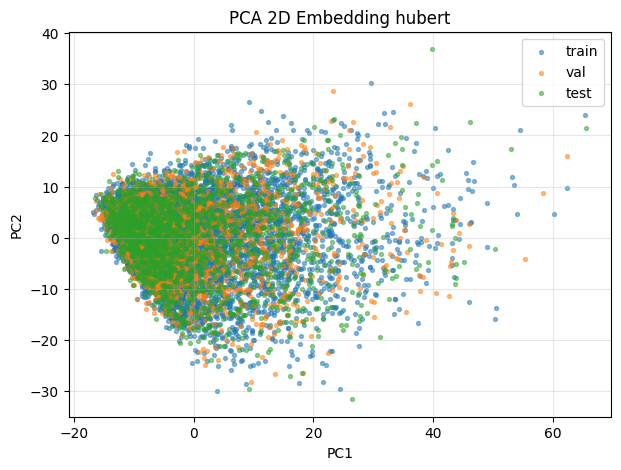

Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\wav2vec2_pca_2d.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\wav2vec2_embedding_pca_2d.png


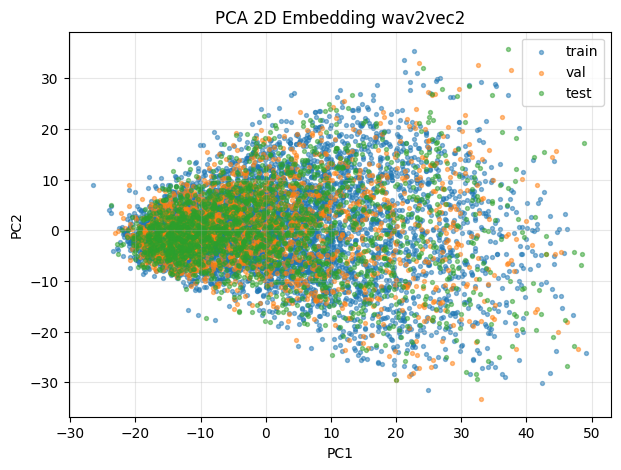

Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\wavlm_pca_2d.csv
Saved figure: e:\tugas-akhir-qiqi\code\V2\output\figures\wavlm_embedding_pca_2d.png


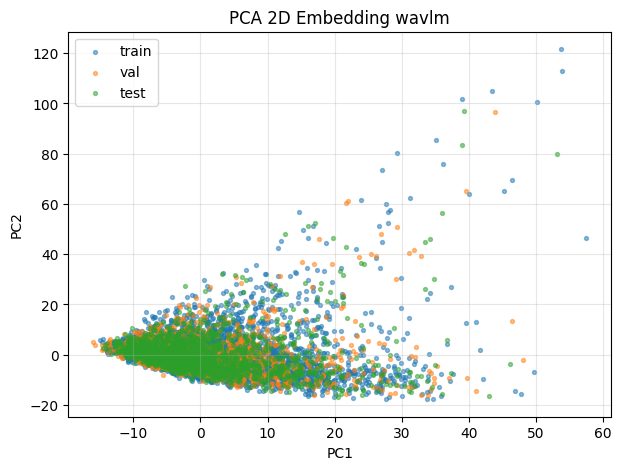

,model,explained_variance_pc1,explained_variance_pc2,explained_variance_total_2d
0,hubert,0.160208,0.077032,0.237240
1,wav2vec2,0.256492,0.088377,0.344869
2,wavlm,0.099939,0.078082,0.178021


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\ssl_embedding_pca_summary.csv


In [30]:
# =========================
# CELL 30: PCA 2D SSL EMBEDDINGS
# =========================

if HAS_SKLEARN:
    pca_summary_rows = []

    for model_name, split_data in ssl_embeddings.items():
        all_embs = []
        all_clip_ids = []
        all_splits = []

        for item in split_data:
            emb = item["embedding"]

            if emb.ndim != 2:
                print(f"[{model_name}] embedding bukan 2D, PCA dilewati.")
                continue

            all_embs.append(emb)
            all_clip_ids.extend(item["clip_id"])
            all_splits.extend([item["split"]] * emb.shape[0])

        if not all_embs:
            continue

        X = np.vstack(all_embs)
        clip_ids = np.array(all_clip_ids)
        splits = np.array(all_splits)

        # Standardize sebelum PCA
        X_scaled = StandardScaler().fit_transform(X)

        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(X_scaled)

        df_pca = pd.DataFrame({
            "clip_id": clip_ids,
            "split": splits,
            "pc1": X_pca[:, 0],
            "pc2": X_pca[:, 1],
        })

        save_table(df_pca, f"{model_name}_pca_2d.csv")

        pca_summary_rows.append({
            "model": model_name,
            "explained_variance_pc1": pca.explained_variance_ratio_[0],
            "explained_variance_pc2": pca.explained_variance_ratio_[1],
            "explained_variance_total_2d": pca.explained_variance_ratio_.sum(),
        })

        plt.figure(figsize=(7, 5))

        for split in ["train", "val", "test"]:
            mask = df_pca["split"] == split
            plt.scatter(
                df_pca.loc[mask, "pc1"],
                df_pca.loc[mask, "pc2"],
                s=8,
                alpha=0.5,
                label=split,
            )

        plt.title(f"PCA 2D Embedding {model_name}")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.legend()
        plt.grid(alpha=0.3)
        save_fig(f"{model_name}_embedding_pca_2d.png")
        plt.show()

    df_pca_summary = pd.DataFrame(pca_summary_rows)
    display(df_pca_summary)
    save_table(df_pca_summary, "ssl_embedding_pca_summary.csv")

else:
    print("scikit-learn tidak tersedia. PCA dilewati.")

In [31]:
# =========================
# CELL 31: FEATURE REPRESENTATION SUMMARY TABLE
# =========================

representation_rows = []

representation_rows.append({
    "representasi": "Metadata + Label",
    "sumber": "meta_train/val/test_official.csv",
    "jumlah_sampel": len(df_meta),
    "dimensi": len(df_meta.columns),
    "keterangan": "Memuat clip_id, group_id, split official, metadata, dan label Big Five"
})

representation_rows.append({
    "representasi": "Audio WAV",
    "sumber": "preprocessed_full",
    "jumlah_sampel": int(df_meta["audio_exists"].sum()),
    "dimensi": "16 kHz mono, 15 detik",
    "keterangan": "Audio hasil standardisasi untuk kebutuhan preview sinyal dan ekstraksi fitur"
})

representation_rows.append({
    "representasi": "eGeMAPS",
    "sumber": "baseline_official/egemaps",
    "jumlah_sampel": len(df_egemaps),
    "dimensi": len(egemaps_feature_cols),
    "keterangan": "Fitur handcrafted akustik"
})

for model_name, split_data in ssl_embeddings.items():
    total_samples = sum(item["embedding"].shape[0] for item in split_data)
    dims = []
    for item in split_data:
        emb = item["embedding"]
        if emb.ndim == 2:
            dims.append(emb.shape[1])

    representation_rows.append({
        "representasi": model_name,
        "sumber": str(SSL_DIRS[model_name]),
        "jumlah_sampel": total_samples,
        "dimensi": dims[0] if dims else "unknown",
        "keterangan": "Embedding SSL pooled per klip"
    })

df_representation_summary = pd.DataFrame(representation_rows)

display(df_representation_summary)
save_table(df_representation_summary, "feature_representation_summary.csv")

,representasi,sumber,jumlah_sampel,dimensi,keterangan
0,Metadata + Label,meta_train/val/test_official.csv,10000,16,"Memuat clip_id, group_id, split official, meta..."
1,Audio WAV,preprocessed_full,10000,"16 kHz mono, 15 detik",Audio hasil standardisasi untuk kebutuhan prev...
2,eGeMAPS,baseline_official/egemaps,9974,88,Fitur handcrafted akustik
3,hubert,E:\tugas-akhir-qiqi\output\V1\baseline_officia...,9974,768,Embedding SSL pooled per klip
4,wav2vec2,E:\tugas-akhir-qiqi\output\V1\baseline_officia...,9974,768,Embedding SSL pooled per klip
5,wavlm,E:\tugas-akhir-qiqi\output\V1\baseline_officia...,9974,768,Embedding SSL pooled per klip


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\feature_representation_summary.csv


WindowsPath('e:/tugas-akhir-qiqi/code/V2/output/tables/feature_representation_summary.csv')

In [32]:
# =========================
# CELL 32: COMPARE METADATA COUNT WITH FEATURE FILES
# =========================

count_check_rows = []

count_check_rows.append({
    "source": "metadata_all",
    "count": len(df_meta),
    "unique_clip_id": df_meta["clip_id"].nunique()
})

count_check_rows.append({
    "source": "egemaps_all",
    "count": len(df_egemaps),
    "unique_clip_id": df_egemaps["clip_id"].nunique()
})

for model_name, split_data in ssl_embeddings.items():
    all_clip_ids = []
    total_count = 0

    for item in split_data:
        total_count += item["embedding"].shape[0]
        all_clip_ids.extend(item["clip_id"])

    count_check_rows.append({
        "source": f"{model_name}_embedding_all",
        "count": total_count,
        "unique_clip_id": len(set(all_clip_ids))
    })

df_count_check = pd.DataFrame(count_check_rows)

display(df_count_check)
save_table(df_count_check, "metadata_feature_count_check.csv")

,source,count,unique_clip_id
0,metadata_all,10000,10000
1,egemaps_all,9974,9974
2,hubert_embedding_all,9974,9974
3,wav2vec2_embedding_all,9974,9974
4,wavlm_embedding_all,9974,9974


Saved table: e:\tugas-akhir-qiqi\code\V2\output\tables\metadata_feature_count_check.csv


WindowsPath('e:/tugas-akhir-qiqi/code/V2/output/tables/metadata_feature_count_check.csv')

In [33]:
# =========================
# CELL 33: GENERATE MARKDOWN EDA SUMMARY
# =========================

report_path = REPORT_DIR / "eda_summary.md"

split_text = split_counts.to_markdown(index=False)
label_stats_text = label_stats.reset_index().rename(columns={"index": "trait"}).to_markdown(index=False)
rep_summary_text = df_representation_summary.to_markdown(index=False)

vad_text = ""
if df_vad is not None:
    vad_text += f"\nJumlah baris VAD report: {len(df_vad)}\n"
    if df_vad_drop is not None:
        vad_text += f"Jumlah data pada vad_drop: {len(df_vad_drop)}\n"

markdown_report = f"""
# EDA Summary Dataset

## Ringkasan Dataset

- Jumlah total klip metadata: {len(df_meta)}
- Jumlah clip_id unik: {df_meta["clip_id"].nunique()}
- Jumlah group_id unik: {df_meta["group_id"].nunique() if "group_id" in df_meta.columns else "N/A"}
- Jumlah trait target: {len(TRAIT_COLS)}
- Trait target: {", ".join(TRAIT_COLS)}
- Modalitas eksperimen: audio-only

## Distribusi Official Split

{split_text}

## Statistik Label Big Five

{label_stats_text}

## Representasi Data dan Fitur

{rep_summary_text}

## Catatan VAD

{vad_text}

## Figure Utama yang Dihasilkan

- bigfive_boxplot.png
- bigfive_correlation_heatmap.png
- avg_trait_distribution.png
- official_split_distribution.png
- gender_distribution.png
- ethnicity_distribution.png
- audio_duration_distribution.png
- waveform/log-mel examples pada folder audio_examples
- PCA embedding untuk HuBERT, wav2vec2, dan WavLM

## Catatan Penulisan untuk Bab 4.1.1

EDA utama dapat menggunakan metadata official sebelum VAD drop dan sebelum strict split.
Visualisasi waveform dan log-mel spectrogram memakai audio hasil standardisasi pada folder preprocessed_full,
sehingga narasi di laporan sebaiknya menyebutkan bahwa visualisasi tersebut digunakan untuk memberi gambaran
sinyal audio yang masuk ke tahap ekstraksi fitur, bukan sebagai representasi audio mentah sebelum preprocessing.

Bagian eGeMAPS dan SSL embedding sebaiknya ditulis sebagai eksplorasi bentuk representasi audio,
bukan sebagai hasil performa model.
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(markdown_report)

print("Saved report:", report_path)

Saved report: e:\tugas-akhir-qiqi\code\V2\output\reports\eda_summary.md


In [34]:
# =========================
# CELL 34: FINAL OUTPUT LIST
# =========================

print("EDA selesai.")
print("\nOutput folder:", OUTPUT_DIR)

print("\nTables:")
for p in sorted(TABLE_DIR.glob("*")):
    print("-", p.name)

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*")):
    print("-", p.name)

print("\nAudio examples:")
for p in sorted(AUDIO_EXAMPLE_DIR.glob("*")):
    print("-", p.name)

print("\nReports:")
for p in sorted(REPORT_DIR.glob("*")):
    print("-", p.name)

EDA selesai.

Output folder: e:\tugas-akhir-qiqi\code\V2\output

Tables:
- age_group_distribution.csv
- audio_availability_summary.csv
- audio_duration_per_clip.csv
- audio_duration_statistics.csv
- avg_trait_statistics.csv
- bigfive_correlation_matrix.csv
- bigfive_label_statistics.csv
- dataset_preview.csv
- dataset_summary.csv
- duplicate_summary.csv
- egemaps_feature_statistics.csv
- egemaps_summary.csv
- ethnicity_distribution.csv
- feature_representation_summary.csv
- gender_distribution.csv
- gender_ethnicity_distribution.csv
- hubert_pca_2d.csv
- metadata_feature_count_check.csv
- metadata_with_vad.csv
- missing_audio_files.csv
- missing_value_summary.csv
- official_split_distribution.csv
- ssl_embedding_norms.csv
- ssl_embedding_pca_summary.csv
- ssl_embedding_summary.csv
- trait_statistics_per_official_split.csv
- vad_drop.csv
- vad_report_preview.csv
- vad_statistics.csv
- wav2vec2_pca_2d.csv
- wavlm_pca_2d.csv

Figures:
- age_group_distribution.png
- agreeableness_by_offici